# DAS Event Classification - Results Visualization

This notebook generates all required figures for the paper comparing:
1. CNN Classifier
2. MLP Classifier  
3. Siamese Multi-Similarity Network

## For each model, we want the:
1. Training curves (loss + accuracy)
2. Confusion matrix
3. F1 score (macro, weighted)
4. Balanced accuracy

### Some imports...

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
import pickle
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',  # Save as PDF
    'font.family': 'serif'
})

### Code to plot confusion matrices in a pretty way

In [3]:
# Pretty Confusion Matrix Functions
# Based on code by Wagner Cipriano and Phongsathorn Kittiworapanya
from pandas import DataFrame
from matplotlib.collections import QuadMesh
from matplotlib.colors import LinearSegmentedColormap

# Create a gradient from white to darker red for better visibility
colors = [(1.0, 0.95, 0.95), (0.95, 0.5, 0.45), (0.8, 0.2, 0.2)]
cm_cmap = LinearSegmentedColormap.from_list('cm_color', colors, N=256)

def get_new_fig(fn, figsize=[9,9]):
    """Init graphics"""
    fig1 = plt.figure(fn, figsize)
    ax1 = fig1.gca()    # Get Current Axis
    ax1.cla()   # clear existing plot
    return fig1, ax1

def configcell_text_and_colors(array_df, lin, col, oText, facecolors, posi, fz, fmt, show_null_values=0):
    """
    config cell text and colors
    and return text elements to add and to dell
    """
    text_add = []
    text_del = []
    cell_val = array_df[lin][col]
    tot_all = array_df[-1][-1]
    per = (float(cell_val) / tot_all) * 100
    curr_column = array_df[:,col]
    ccl = len(curr_column)

    # last line and/or last column
    if(col == (ccl - 1)) or (lin == (ccl - 1)):
        # tots and percents
        if(cell_val != 0):
            if(col == ccl - 1) and (lin == ccl - 1):
                tot_rig = 0
                for i in range(array_df.shape[0] - 1):
                    tot_rig += array_df[i][i]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif(col == ccl - 1):
                tot_rig = array_df[lin][lin]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif(lin == ccl - 1):
                tot_rig = array_df[col][col]
                per_ok = (float(tot_rig) / cell_val) * 100
            per_err = 100 - per_ok
        else:
            per_ok = per_err = 0

        per_ok_s = ['%.2f%%'%(per_ok), '100%'][int(per_ok == 100)]

        # text to DEL
        text_del.append(oText)

        # text to ADD
        font_prop = fm.FontProperties(size=fz)
        text_kwargs = dict(color='black', ha="center", va="center", gid='sum', fontproperties=font_prop)
        lis_txt = ['%d'%(cell_val), per_ok_s, '%.2f%%'%(per_err)]
        lis_kwa = [text_kwargs]
        dic = text_kwargs.copy(); dic['color'] = 'g'; lis_kwa.append(dic);
        dic = text_kwargs.copy(); dic['color'] = 'r'; lis_kwa.append(dic);
        lis_pos = [(oText._x, oText._y-0.25), (oText._x, oText._y), (oText._x, oText._y+0.25)]
        for i in range(len(lis_txt)):
            newText = dict(x=lis_pos[i][0], y=lis_pos[i][1], text=lis_txt[i], kw=lis_kwa[i])
            text_add.append(newText)

        # set background color for sum cells (last line and last column)
        carr = np.array([0.7, 0.7, 0.7, 1.0])
        if(col == ccl - 1) and (lin == ccl - 1):
            carr = np.array([0.5, 0.5, 0.5, 1.0])
        facecolors[posi] = carr

    else:
        if(per > 0):
            txt = '$\\mathbf{%s}$\n%.2f%%' %(cell_val, per)
        else:
            if(show_null_values == 0):
                txt = ''
            elif(show_null_values == 1):
                txt = '0'
            else:
                txt = '$\\mathbf{0}$\n0.0%%'
        oText.set_text(txt)

        # main diagonal
        if(col == lin):
            # set color of the text in the diagonal to black for visibility
            oText.set_color('black')
            # set background color in the diagonal to bright green
            facecolors[posi] = np.array([0.3, 0.9, 0.3, 1.0])

    return text_add, text_del

def insert_totals(df_cm):
    """insert total column and line (the last ones)"""
    sum_col = []
    for c in df_cm.columns:
        sum_col.append(df_cm[c].sum())
    sum_lin = []
    for item_line in df_cm.iterrows():
        sum_lin.append(item_line[1].sum())
    df_cm['sum_lin'] = sum_lin
    sum_col.append(np.sum(sum_lin))
    df_cm.loc['sum_col'] = sum_col

def plot_pretty_confusion_matrix(df_cm, annot=True, cmap=cm_cmap, fmt='.2f', fz=11,
      lw=2, cbar=False, figsize=[5,5], show_null_values=2, pred_val_axis='y'):
    """
    print conf matrix with default layout (like matlab)
    """
    if(pred_val_axis in ('col', 'x')):
        xlbl = 'Predicted'
        ylbl = 'Actual'
    else:
        xlbl = 'Actual'
        ylbl = 'Predicted'
        df_cm = df_cm.T

    # create "Total" column
    insert_totals(df_cm)

    # Create figure
    fig, ax1 = get_new_fig('Conf matrix default', figsize)

    # Get data as numpy array
    data = df_cm.values
    n_rows, n_cols = data.shape
    
    # Create custom color array for each cell
    # Start with all cells using the red colormap
    from matplotlib import cm as mpl_cm
    norm = plt.Normalize(vmin=data.min(), vmax=data.max())
    colors_matrix = np.zeros((n_rows, n_cols, 4))
    
    # Calculate separate normalizations for diagonal and sum cells
    diag_values = [data[i, i] for i in range(min(n_rows - 1, n_cols - 1))]
    sum_values = []
    for i in range(n_rows - 1):
        sum_values.append(data[i, n_cols - 1])
    for j in range(n_cols - 1):
        sum_values.append(data[n_rows - 1, j])
    
    norm_diag = plt.Normalize(vmin=min(diag_values) if diag_values else 0, vmax=max(diag_values) if diag_values else 1)
    norm_sum = plt.Normalize(vmin=min(sum_values) if sum_values else 0, vmax=max(sum_values) if sum_values else 1)
    
    # Apply colors based on cell type
    for i in range(n_rows):
        for j in range(n_cols):
            # Diagonal cells (excluding sum) - GREEN GRADIENT
            if i == j and i < n_rows - 1:
                val = norm_diag(data[i, j])
                # Green gradient: light green to darker green
                colors_matrix[i, j] = [0.7 - val * 0.5, 0.95 - val * 0.15, 0.7 - val * 0.5, 1.0]
            # Sum column (excluding corner) - LIGHT GREEN GRADIENT
            elif j == n_cols - 1 and i < n_rows - 1:
                val = norm_sum(data[i, j])
                colors_matrix[i, j] = [0.85 - val * 0.15, 0.95 - val * 0.1, 0.85 - val * 0.15, 1.0]
            # Sum row (excluding corner) - LIGHT GREEN GRADIENT
            elif i == n_rows - 1 and j < n_cols - 1:
                val = norm_sum(data[i, j])
                colors_matrix[i, j] = [0.85 - val * 0.15, 0.95 - val * 0.1, 0.85 - val * 0.15, 1.0]
            # Corner (total) - LIGHT GRAY
            elif i == n_rows - 1 and j == n_cols - 1:
                colors_matrix[i, j] = [0.9, 0.9, 0.9, 1.0]
            # All other cells - RED gradient (much stronger red)
            else:
                # Use red colormap with much stronger red color
                val = norm(data[i, j])
                # Range from light pink (low values) to strong red (high values)
                colors_matrix[i, j] = [1.0, 0.95 - val * 0.75, 0.95 - val * 0.75, 1.0]
    
    # Draw the heatmap using imshow with our custom colors
    ax1.imshow(colors_matrix, aspect='auto', interpolation='nearest')
    
    # Explicitly turn off grid
    ax1.grid(False)
    
    # Set limits
    ax1.set_xlim(-0.5, n_cols - 0.5)
    ax1.set_ylim(n_rows - 0.5, -0.5)
    
    # Turn off spines (borders)
    for spine in ax1.spines.values():
        spine.set_visible(False)
    
    # Turn off ticks
    ax1.tick_params(axis='both', which='both', length=0)
    
    # Set tick labels
    ax1.set_xticks(range(n_cols))
    ax1.set_yticks(range(n_rows))
    ax1.set_xticklabels(df_cm.columns, ha='right', rotation=45)
    ax1.set_yticklabels(df_cm.index, va='center')

    # Now add text annotations
    array_df = np.array(df_cm.to_records(index=False).tolist())
    for i in range(n_rows):
        for j in range(n_cols):
            cell_val = array_df[i][j]
            tot_all = array_df[-1][-1]
            per = (float(cell_val) / tot_all) * 100
            
            # Sum cells
            if i == n_rows - 1 or j == n_cols - 1:
                if cell_val != 0:
                    if i == n_rows - 1 and j == n_cols - 1:
                        tot_rig = sum(array_df[k][k] for k in range(n_rows - 1))
                        per_ok = (float(tot_rig) / cell_val) * 100
                    elif j == n_cols - 1:
                        tot_rig = array_df[i][i]
                        per_ok = (float(tot_rig) / cell_val) * 100
                    else:
                        tot_rig = array_df[j][j]
                        per_ok = (float(tot_rig) / cell_val) * 100
                    per_err = 100 - per_ok
                    per_ok_s = '100%' if per_ok == 100 else f'{per_ok:.2f}%'
                    
                    ax1.text(j, i - 0.25, f'{int(cell_val)}', 
                           ha='center', va='center', fontsize=fz, color='black')
                    ax1.text(j, i, per_ok_s, 
                           ha='center', va='center', fontsize=fz, color='g')
                    ax1.text(j, i + 0.25, f'{per_err:.2f}%', 
                           ha='center', va='center', fontsize=fz, color='r')
            # Regular cells
            else:
                if per > 0:
                    txt = f'$\\mathbf{{{int(cell_val)}}}$\n{per:.2f}%'
                else:
                    txt = '' if show_null_values == 0 else ('0' if show_null_values == 1 else '$\\mathbf{0}$\n0.0%')
                
                ax1.text(j, i, txt, ha='center', va='center', fontsize=fz, color='black')

    # Labels
    ax1.set_xlabel(xlbl, fontdict={"weight": "bold"})
    ax1.set_ylabel(ylbl, fontdict={"weight": "bold"})
    
    plt.tight_layout()

def plot_from_confusion_matrix(cm, columns=None, annot=True, cmap=cm_cmap,
      fmt='.2f', fz=11, lw=1, cbar=False, figsize=[5,5], show_null_values=2, pred_val_axis='lin'):
    """Plot confusion matrix from a confusion matrix array."""
    df_cm = DataFrame(cm, index=columns, columns=columns)
    plot_pretty_confusion_matrix(df_cm, fz=fz, lw=lw, cmap=cmap, figsize=figsize, show_null_values=show_null_values, pred_val_axis=pred_val_axis)

print("✓ Pretty confusion matrix functions loaded")

✓ Pretty confusion matrix functions loaded


## 1. Load Results from All Models

In [8]:
# Define result directories (update these paths after training)
CNN_DIR = "cnn_results_20260120_094712"  
MLP_DIR = "mlp_results_20260122_040240"  # Best MLP: batch=256, dropout=0.3, 76.08%
SIAMESE_DIR = "siamese_multisim_20260126_035856"  # Best: L2/Cosine in testing (46.38% on 9-class, 50.47% on 9-way 10-shot)
SIAMESE_PY_DIR = "checkpoints/siamese_py_run_20260127_033100"  # siamese.py training results
OUTPUT_DIR = "paper_figures"

Path(OUTPUT_DIR).mkdir(exist_ok=True)

def load_results(result_dir, model_name):
    """Load saved results from a training run."""
    results = {'name': model_name, 'dir': result_dir}
    
    # Try loading history (training curves)
    history_file = Path(result_dir) / 'history.npy'
    if history_file.exists():
        results['history'] = np.load(history_file, allow_pickle=True).item()
        print(f"✓ Loaded {model_name} training history")
    else:
        results['history'] = None
    
    # Try loading test results - prefer .npy over .json
    test_npy = Path(result_dir) / 'test_results.npy'
    test_json = Path(result_dir) / 'test_results.json'
    
    if test_npy.exists():
        results['test'] = np.load(test_npy, allow_pickle=True).item()
        print(f"✓ Loaded {model_name} test results")
    elif test_json.exists():
        with open(test_json, 'r') as f:
            results['test'] = json.load(f)
        print(f"✓ Loaded {model_name} test results")
    else:
        results['test'] = None
    
    # Try loading comprehensive results (pkl format)
    pkl_files = list(Path(result_dir).glob('*classification_report*.pkl'))
    if pkl_files:
        with open(pkl_files[0], 'rb') as f:
            results['pkl'] = pickle.load(f)
        print(f"✓ Loaded {model_name} comprehensive results (pkl)")
    else:
        results['pkl'] = None
    
    # Try loading test results for 5-class problem
    test_5class_file = Path(result_dir) / 'test_5class_results.json'
    if test_5class_file.exists():
        with open(test_5class_file, 'r') as f:
            results['test_5class'] = json.load(f)
        print(f"✓ Loaded {model_name} 5-class test results")
    else:
        results['test_5class'] = None
    
    return results

In [9]:
# Load all results
print("Loading results...\n")
cnn_results = load_results(CNN_DIR, 'CNN')
mlp_results = load_results(MLP_DIR, 'MLP')
siamese_results = load_results(SIAMESE_DIR, 'Siamese')
print("\nDone!")

Loading results...

✓ Loaded CNN training history
✓ Loaded CNN test results
✓ Loaded MLP training history
✓ Loaded MLP test results
✓ Loaded Siamese training history
✓ Loaded Siamese test results

Done!


## 2. Individual Model Visualizations

### 2.1 CNN Classifier

Ploting accuracy and loss...

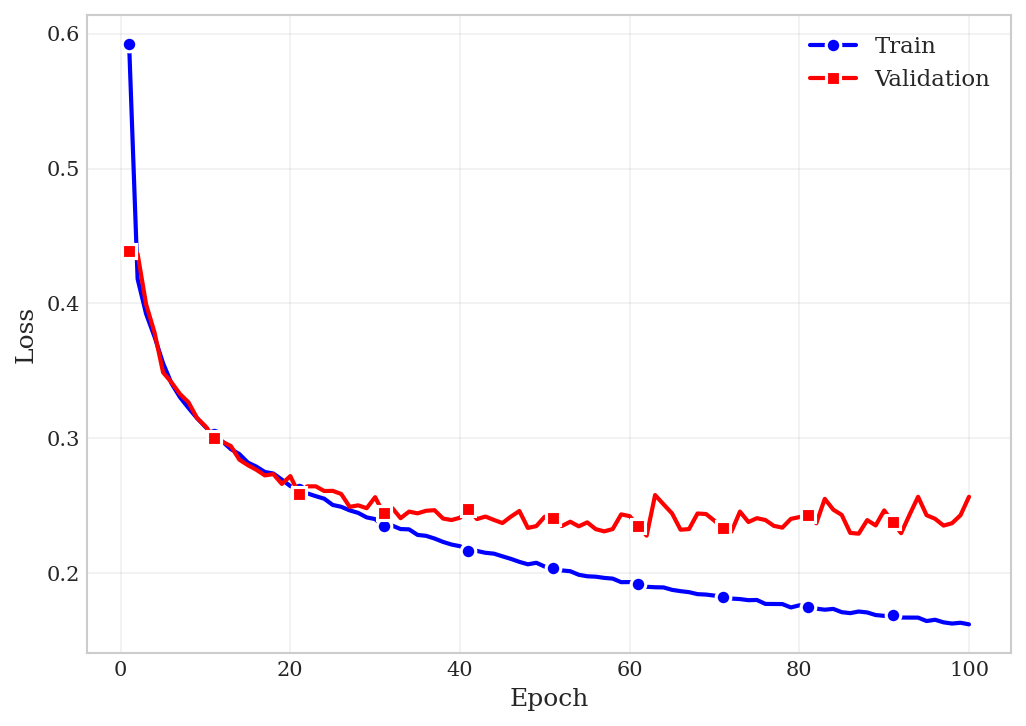

✓ Saved: paper_figures/cnn_loss.pdf


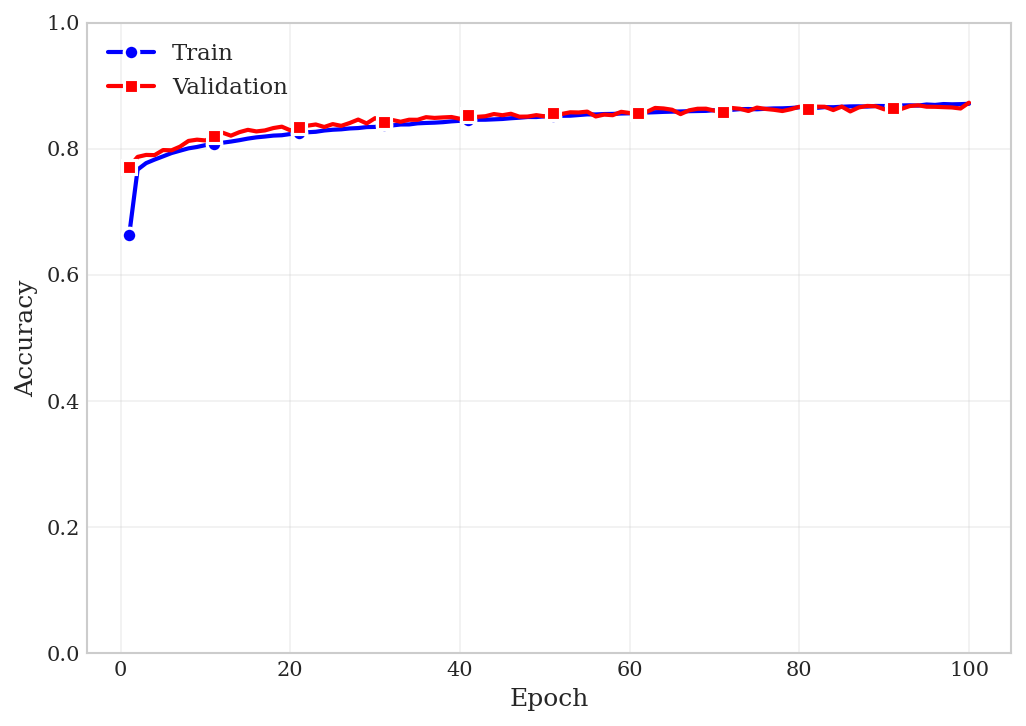

✓ Saved: paper_figures/cnn_accuracy.pdf


In [14]:
def plot_loss_curve(history, model_name, filename):
    """Plot loss curve (train and validation)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss with markers
    ax.plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2, 
            marker='o', markersize=7, markevery=10, 
            markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2,
            marker='s', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    # No title - will be in LaTeX caption
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()
    print(f"✓ Saved: {filename}")

def plot_accuracy_curve(history, model_name, filename):
    """Plot accuracy curve (train and validation)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Determine accuracy key names (Siamese uses different keys)
    train_acc_key = 'train_pair_acc' if 'train_pair_acc' in history else 'train_acc'
    val_acc_key = 'val_pair_acc' if 'val_pair_acc' in history else 'val_acc'
    
    # Accuracy with markers
    ax.plot(epochs, history[train_acc_key], 'b-', label='Train', linewidth=2, 
            marker='o', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(epochs, history[val_acc_key], 'r-', label='Validation', linewidth=2, 
            marker='s', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    # No title - will be in LaTeX caption
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()

    print(f"✓ Saved: {filename}")

# Plot CNN curves
if cnn_results['history'] is not None:
    plot_loss_curve(
        cnn_results['history'],
        'CNN',
        f'{OUTPUT_DIR}/cnn_loss.pdf'
    )
    plot_accuracy_curve(
        cnn_results['history'],
        'CNN',
        f'{OUTPUT_DIR}/cnn_accuracy.pdf'
    )

Ploting confusion matrix...

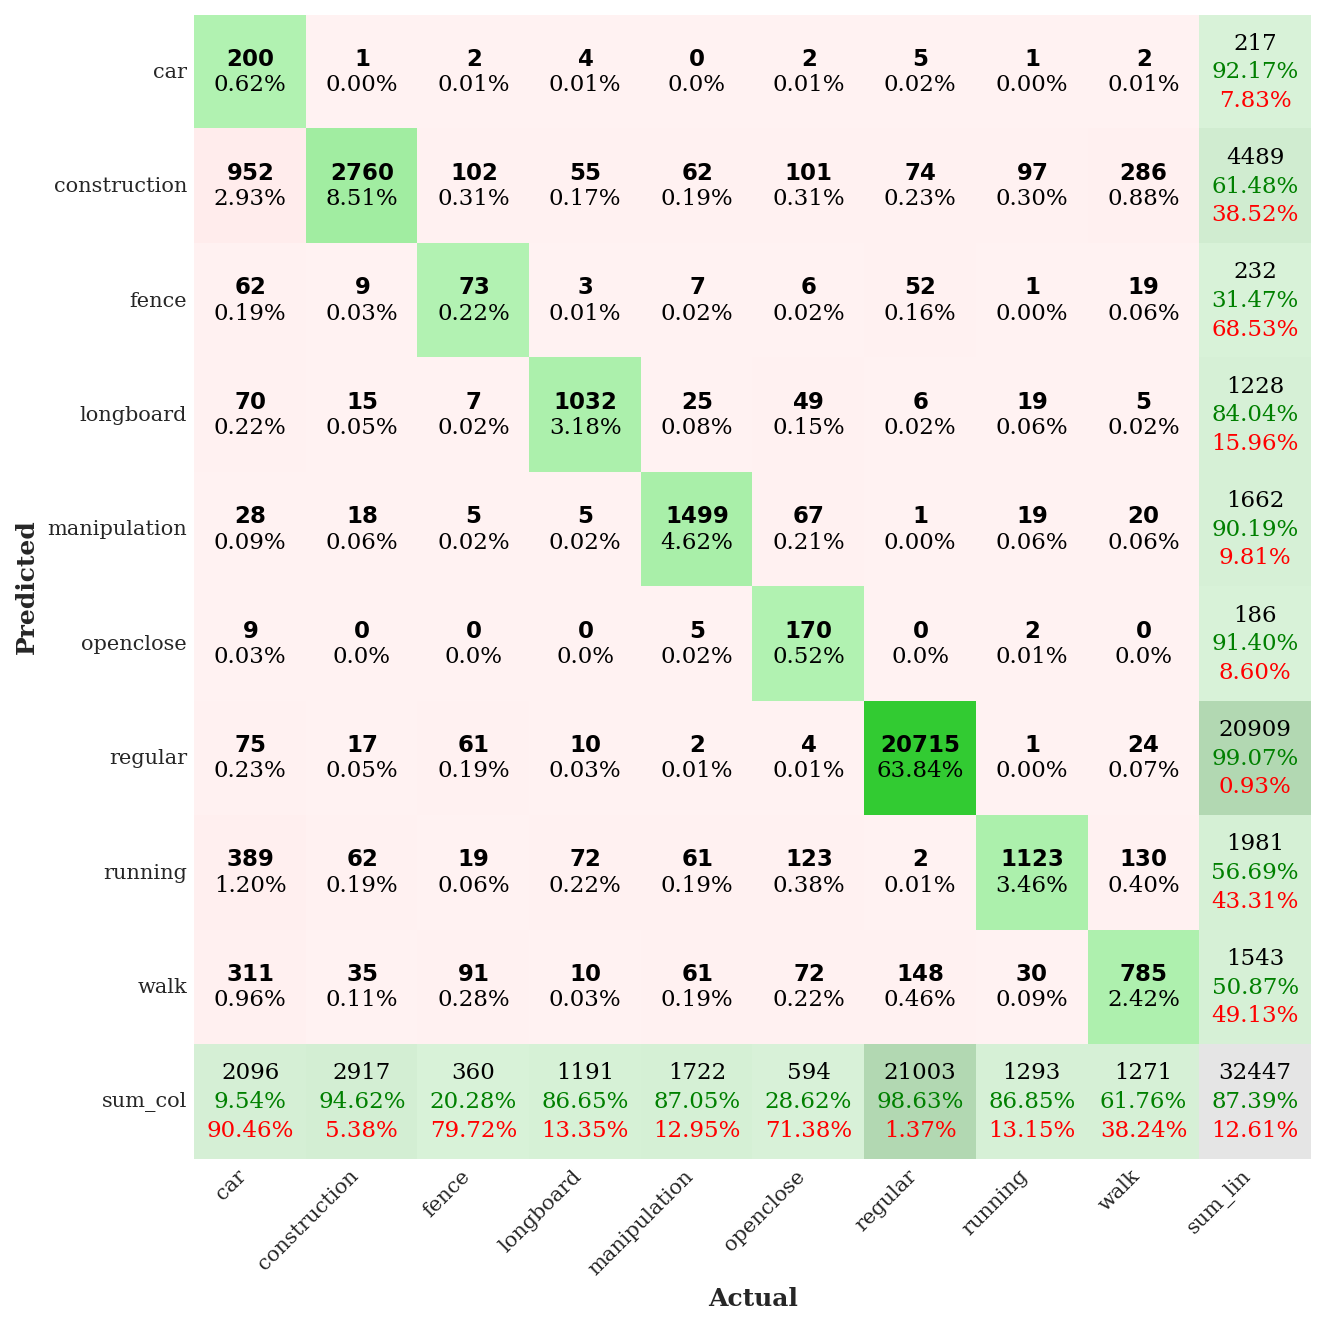

✓ Saved: paper_figures/cnn_confusion_matrix.pdf


In [15]:
def plot_confusion_matrix(cm, class_names, filename):
    """Plot confusion matrix using pretty visualization."""
    # Close any existing figures to avoid conflicts
    plt.close('all')
    
    # Use the pretty confusion matrix function
    plot_from_confusion_matrix(
        cm, 
        columns=class_names, 
        figsize=[9, 9], 
        fz=11, 
        lw=1, 
        show_null_values=2, 
        pred_val_axis='lin'
    )
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close('all')
    print(f"✓ Saved: {filename}")

# Plot CNN confusion matrix
if cnn_results['test'] is not None and 'confusion_matrix' in cnn_results['test']:
    plot_confusion_matrix(
        cnn_results['test']['confusion_matrix'],
        cnn_results['test'].get('class_names', [f'Class {i}' for i in range(9)]),
        f'{OUTPUT_DIR}/cnn_confusion_matrix.pdf'
    )

Ploting the results summary for this model...

In [16]:
def print_metrics_summary(test_results, model_name):
    """Print summary of key metrics."""
    print(f"\n{'='*60}")
    print(f"{model_name} - Test Results")
    print(f"{'='*60}")
    print(f"Accuracy:          {test_results.get('accuracy', 0):.4f}")
    print(f"Balanced Accuracy: {test_results.get('balanced_accuracy', 0):.4f}")
    print(f"F1 Score (Macro):  {test_results.get('f1_macro', 0):.4f}")
    print(f"F1 Score (Weighted): {test_results.get('f1_weighted', 0):.4f}")
    print(f"{'='*60}\n")

# Print CNN metrics
if cnn_results['test'] is not None:
    print_metrics_summary(cnn_results['test'], 'CNN')


CNN - Test Results
Accuracy:          0.8739
Balanced Accuracy: 0.6378
F1 Score (Macro):  0.6192
F1 Score (Weighted): 0.8563



### 2.2 MLP Classifier

Ploting accuracy, loss, confusion matrix, and results summary...

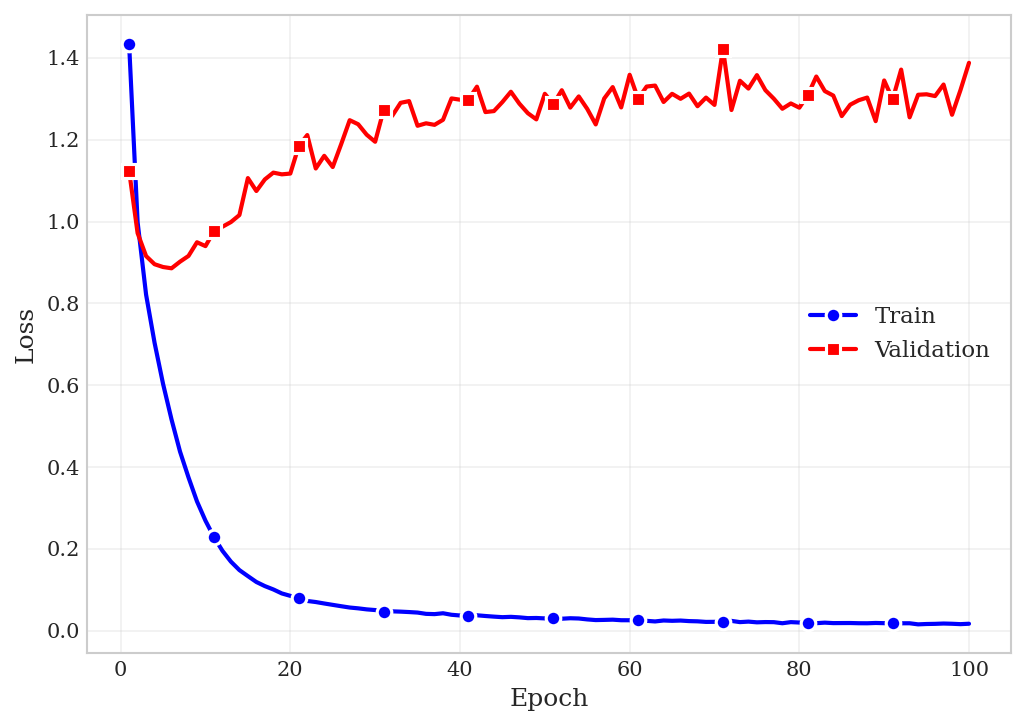

✓ Saved: paper_figures/mlp_loss.pdf


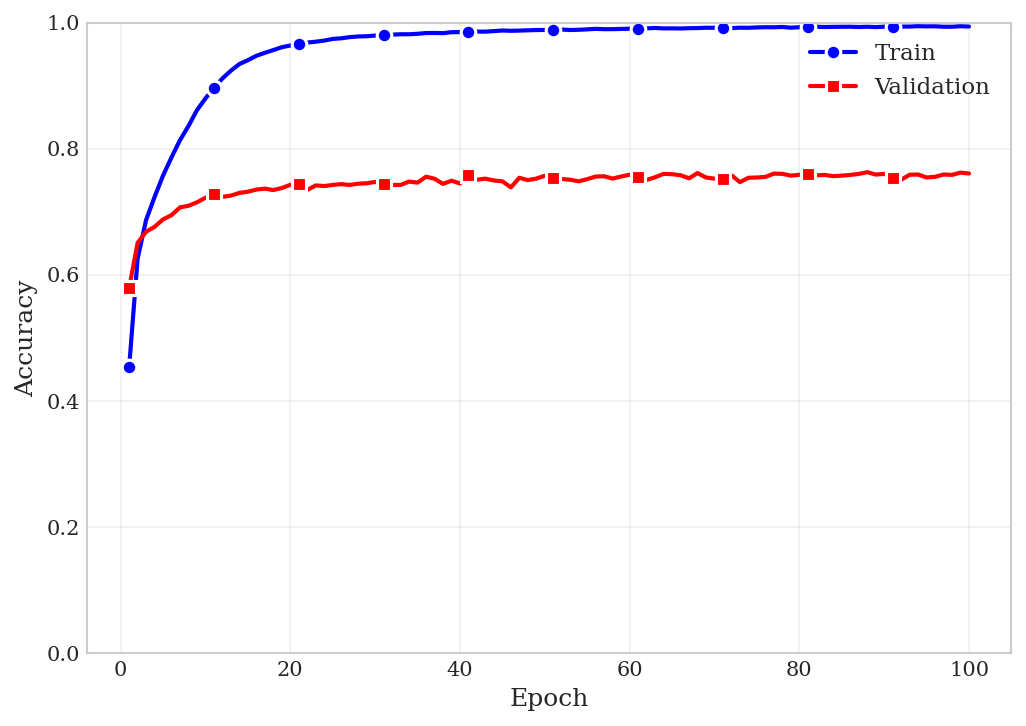

✓ Saved: paper_figures/mlp_accuracy.pdf


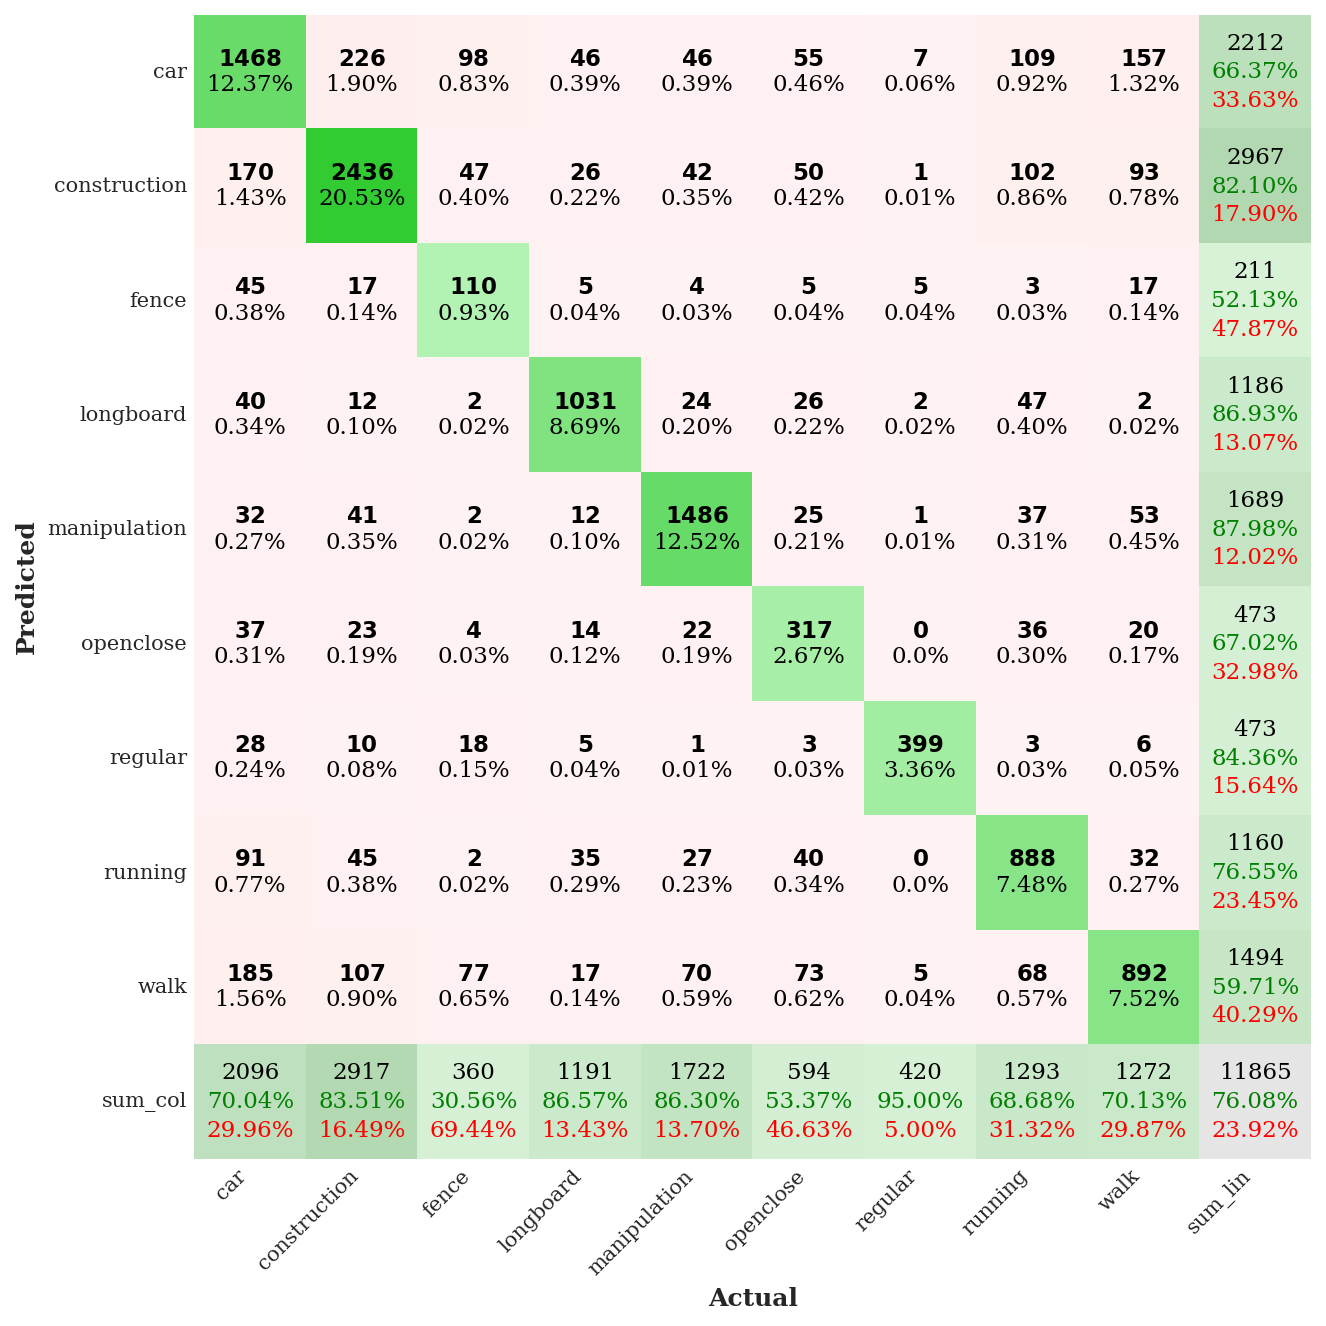

✓ Saved: paper_figures/mlp_confusion_matrix.pdf

MLP - Test Results
Accuracy:          0.7608
Balanced Accuracy: 0.7157
F1 Score (Macro):  0.7212
F1 Score (Weighted): 0.7586



In [17]:
# Plot MLP curves
if mlp_results['history'] is not None:
    plot_loss_curve(
        mlp_results['history'],
        'MLP',
        f'{OUTPUT_DIR}/mlp_loss.pdf'
    )
    plot_accuracy_curve(
        mlp_results['history'],
        'MLP',
        f'{OUTPUT_DIR}/mlp_accuracy.pdf'
    )

# Plot MLP confusion matrix
if mlp_results['test'] is not None and 'confusion_matrix' in mlp_results['test']:
    plot_confusion_matrix(
        mlp_results['test']['confusion_matrix'],
        mlp_results['test'].get('class_names', [f'Class {i}' for i in range(9)]),
        f'{OUTPUT_DIR}/mlp_confusion_matrix.pdf'
    )

# Print MLP metrics
if mlp_results['test'] is not None:
    print_metrics_summary(mlp_results['test'], 'MLP')

### 2.3 Siamese Multi-Similarity Network

Ploting accuracy and loss

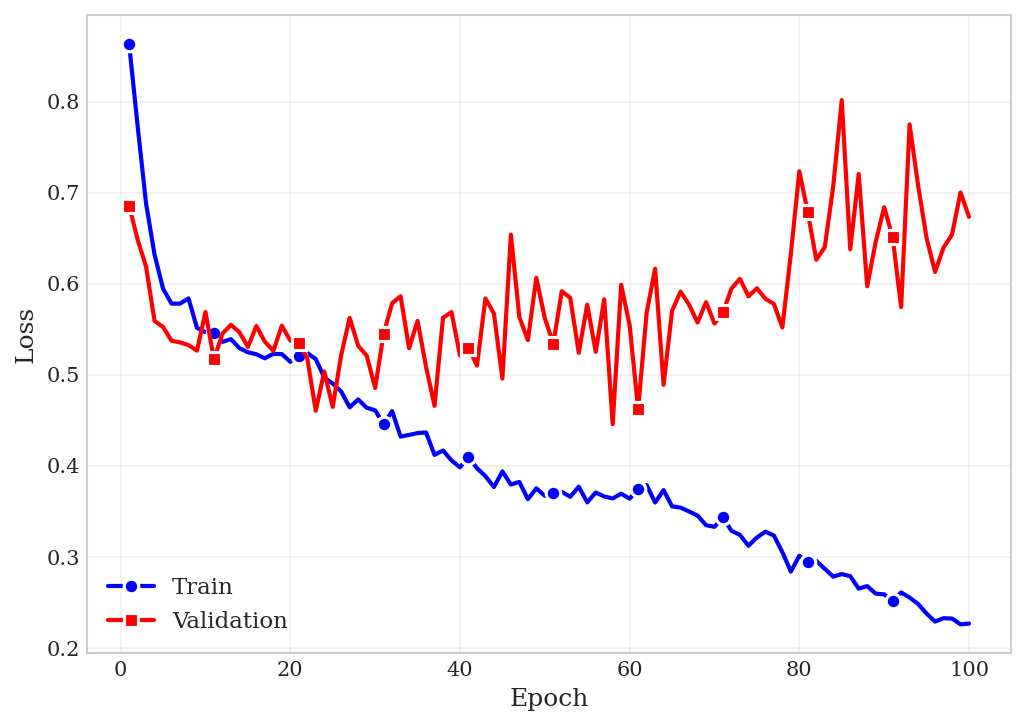

✓ Saved: paper_figures/siamese_loss.pdf


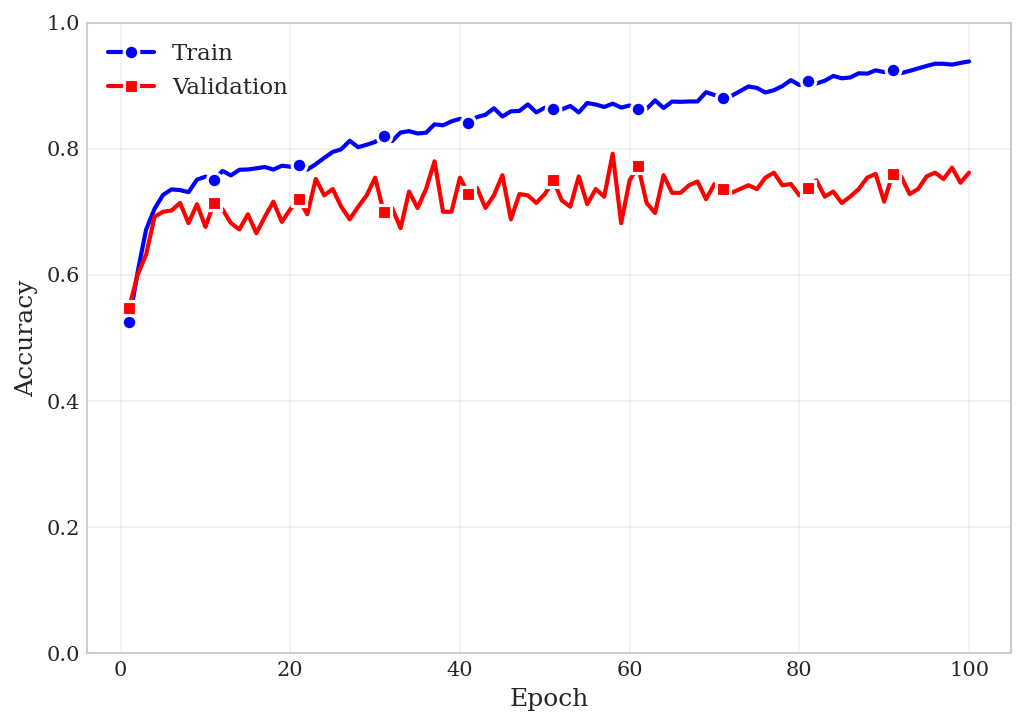

✓ Saved: paper_figures/siamese_accuracy.pdf

Siamese - Test Results (9-way 20-shot)
Test Samples:      4,867
Accuracy:          0.7775
Balanced Accuracy: 0.5074
F1 Score (Macro):  0.4739
F1 Score (Weighted): 0.7850



In [19]:
# Plot Siamese curves
if siamese_results['history'] is not None:
    plot_loss_curve(
        siamese_results['history'],
        'Siamese',
        f'{OUTPUT_DIR}/siamese_loss.pdf'
    )
    plot_accuracy_curve(
        siamese_results['history'],
        'Siamese',
        f'{OUTPUT_DIR}/siamese_accuracy.pdf'
    )

# Display metrics from full test set (9-way 20-shot)
full_test_file = f'{OUTPUT_DIR}/siamese_full_test_results.pkl'
try:
    with open(full_test_file, 'rb') as f:
        full_test_results_temp = pickle.load(f)
    if '9way_20shot' in full_test_results_temp:
        siamese_full_test = full_test_results_temp['9way_20shot']
        print(f"\n{'='*60}")
        print(f"Siamese - Test Results (9-way 20-shot)")
        print(f"{'='*60}")
        print(f"Test Samples:      {len(siamese_full_test['predictions']):,}")
        print(f"Accuracy:          {siamese_full_test['accuracy']:.4f}")
        print(f"Balanced Accuracy: {siamese_full_test['balanced_accuracy']:.4f}")
        print(f"F1 Score (Macro):  {siamese_full_test['f1_macro']:.4f}")
        print(f"F1 Score (Weighted): {siamese_full_test['f1_weighted']:.4f}")
        print(f"{'='*60}\n")
except FileNotFoundError:
    print(f"⚠ Full test results not found, using episodic evaluation results")
    if siamese_results['test'] is not None:
        print_metrics_summary(siamese_results['test'], 'Siamese (Episodic)')

#### N-way K-shot Confusion Matrices (Full Test Set)

In [ ]:
# Load full test set results - NEW RESULTS (no decimation)
import pickle

# Use the new results with no decimation (same dataset as original CNN)
full_test_file = 'siamese_no_decimation_results/siamese_full_test_results.pkl'

try:
    with open(full_test_file, 'rb') as f:
        full_test_results = pickle.load(f)
    print(f"✓ Loaded full test set results from {full_test_file}")
    print(f"  Configurations available: {list(full_test_results.keys())}")
    print(f"\n  Using NEW evaluation: No decimation (same as CNN)")
    print(f"  Test samples: ~48,676 (same dataset as original CNN)")
except FileNotFoundError:
    print(f"⚠ Full test results not found: {full_test_file}")
    full_test_results = None

✓ Loaded full test set results from paper_figures/siamese_full_test_results.pkl
  Configurations available: ['5way_1shot', '5way_5shot', '5way_10shot', '5way_15shot', '5way_20shot', '9way_1shot', '9way_5shot', '9way_10shot', '9way_15shot', '9way_20shot', 'anomaly_detection']



9-way 1-shot Confusion Matrix
Accuracy: 0.7446
Balanced Accuracy: 0.4500
F1 Macro: 0.3882

✓ Saved: paper_figures/siamese_9way_1shot_confusion_matrix.pdf


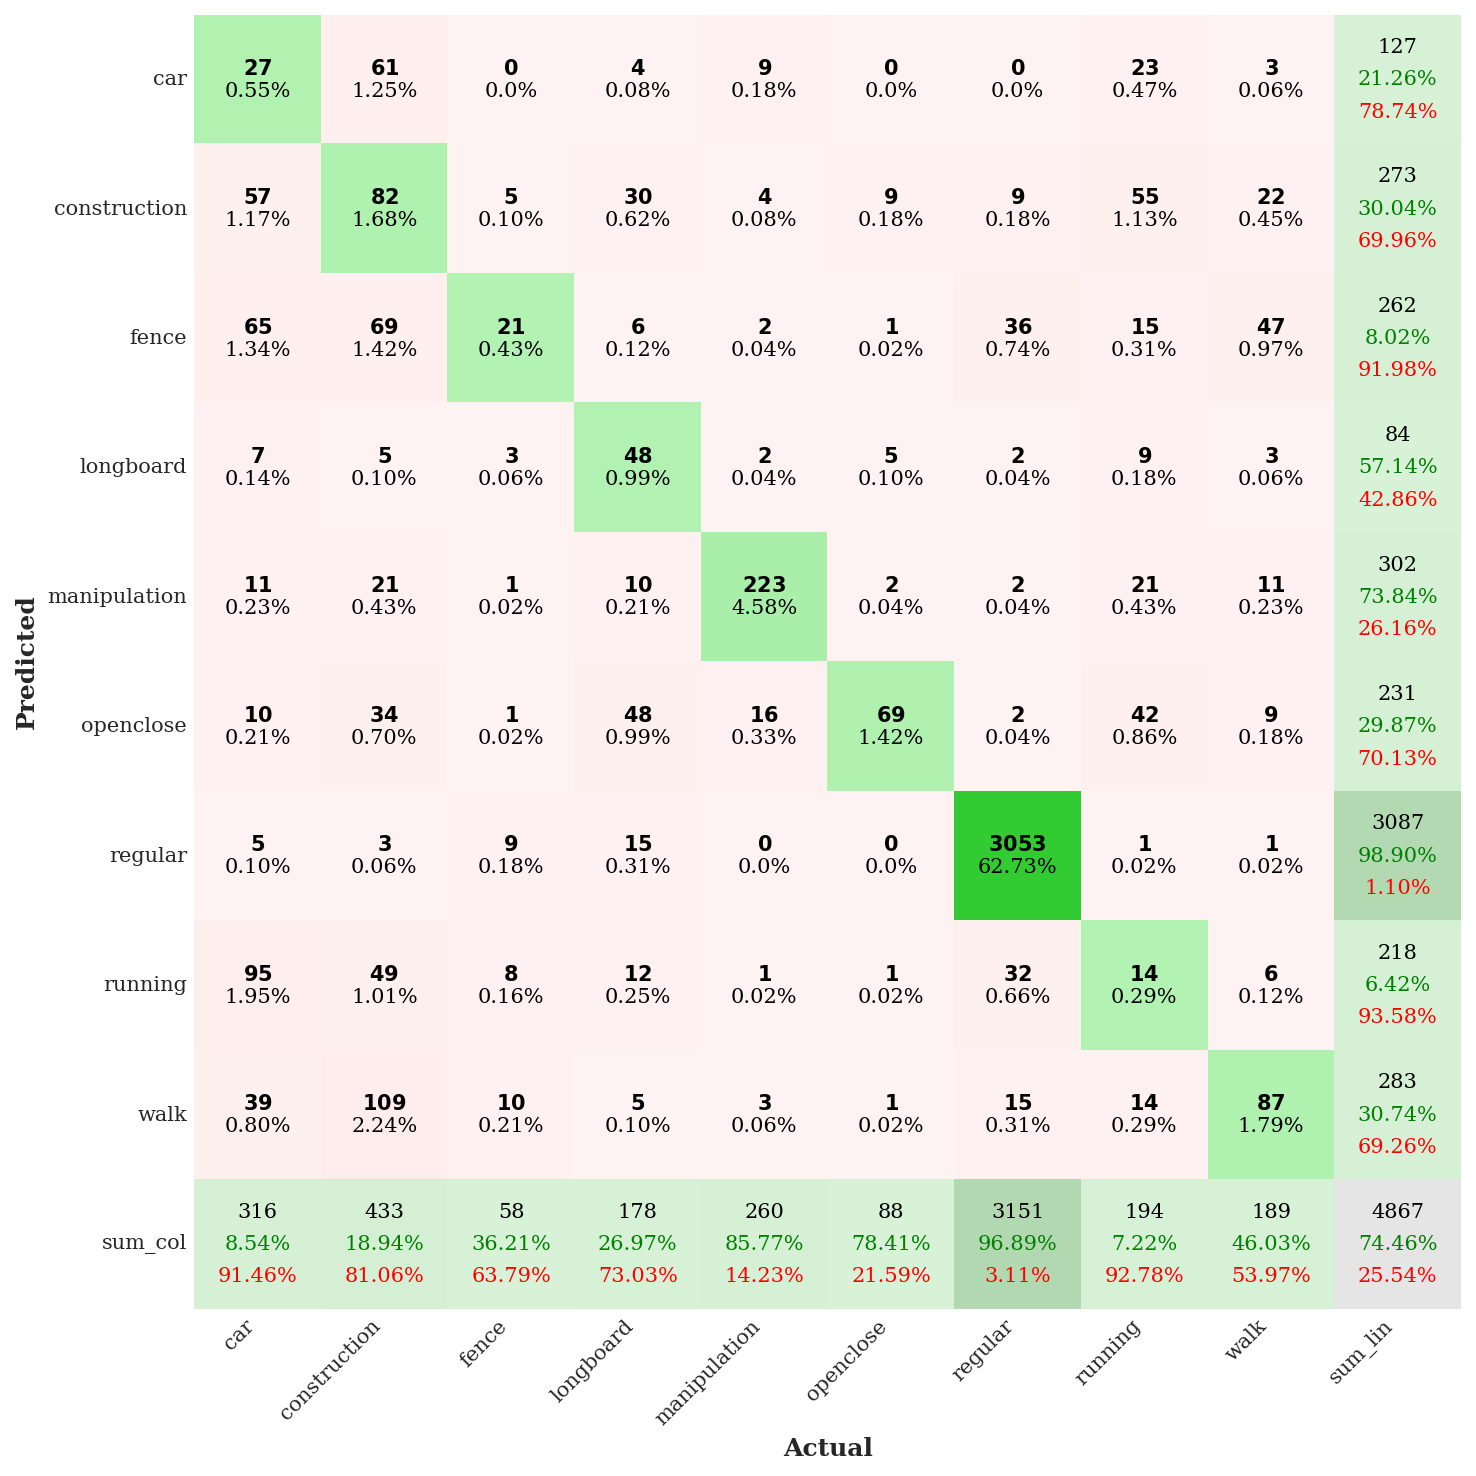


9-way 5-shot Confusion Matrix
Accuracy: 0.7573
Balanced Accuracy: 0.4581
F1 Macro: 0.4234

✓ Saved: paper_figures/siamese_9way_5shot_confusion_matrix.pdf


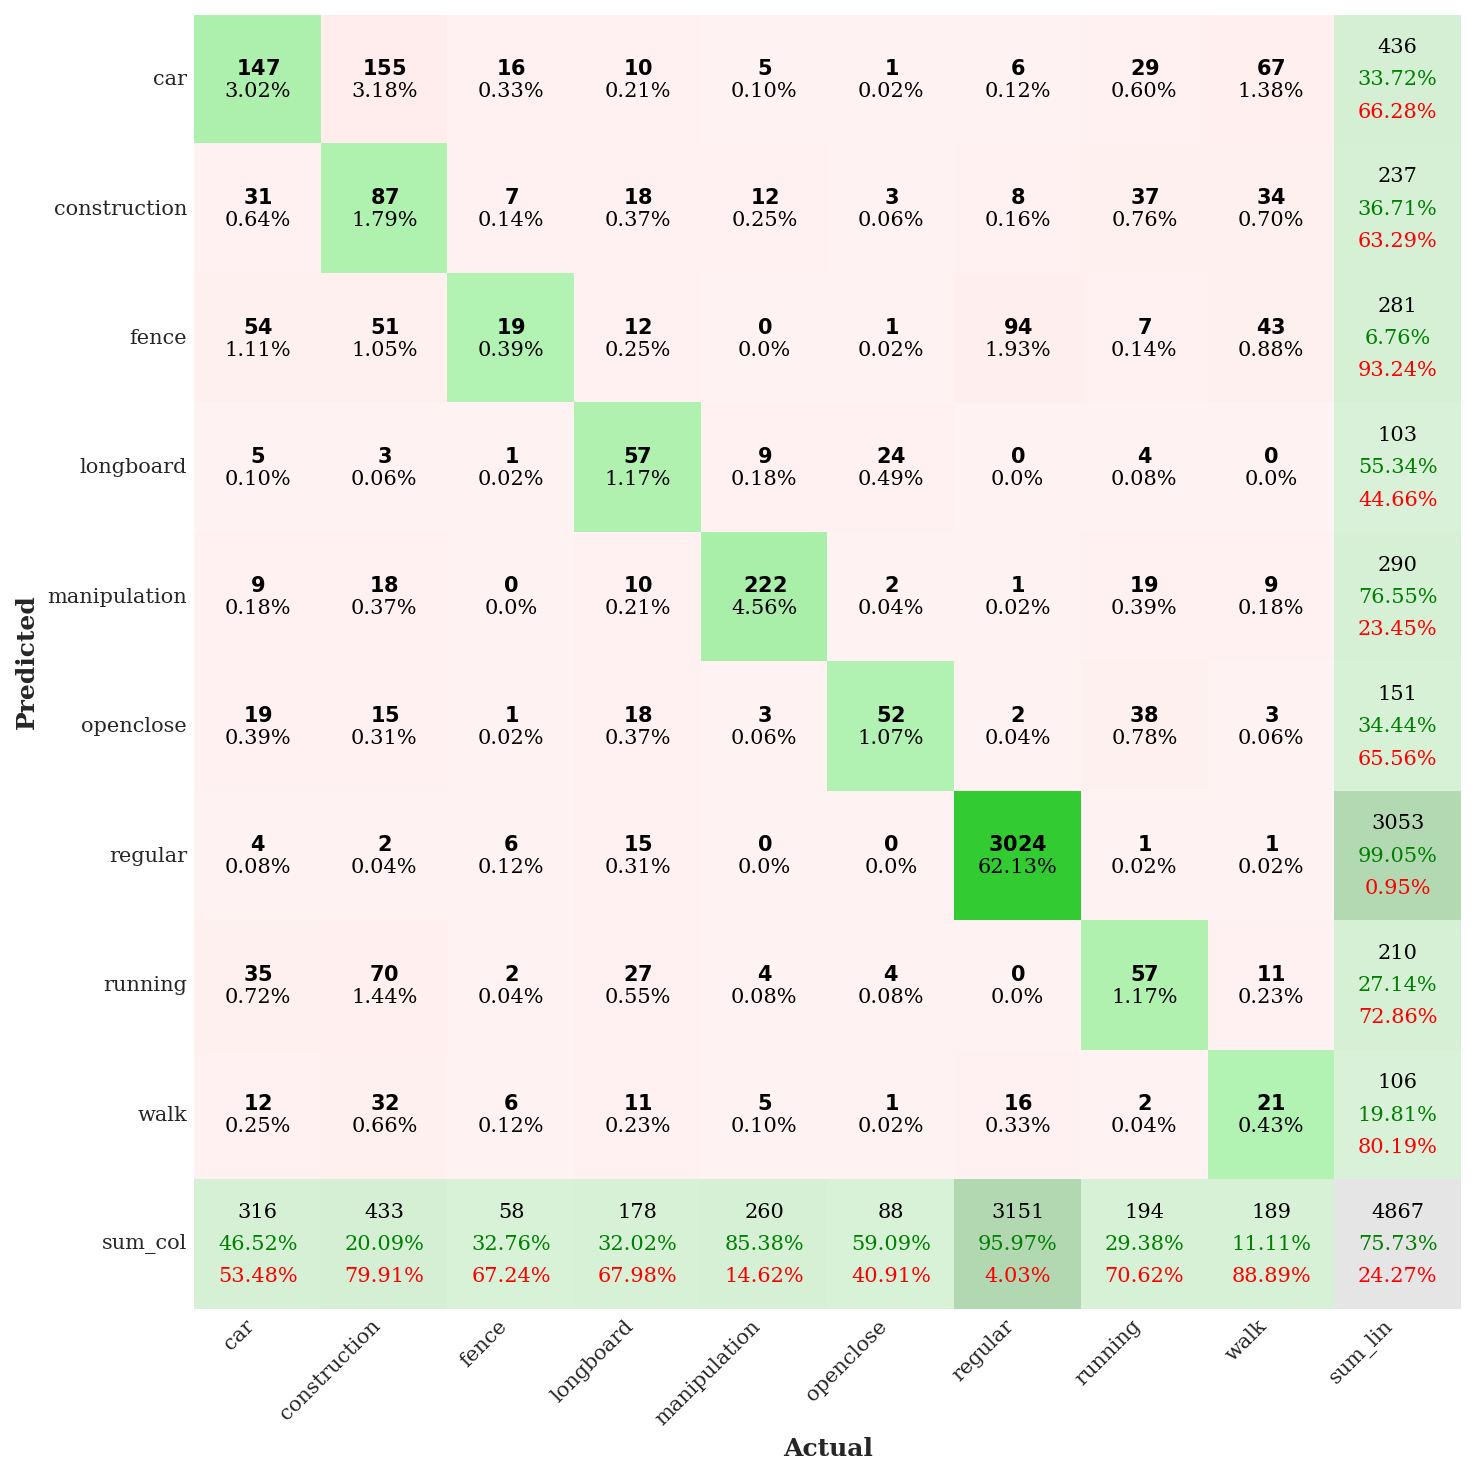


9-way 10-shot Confusion Matrix
Accuracy: 0.7728
Balanced Accuracy: 0.4966
F1 Macro: 0.4593

✓ Saved: paper_figures/siamese_9way_10shot_confusion_matrix.pdf


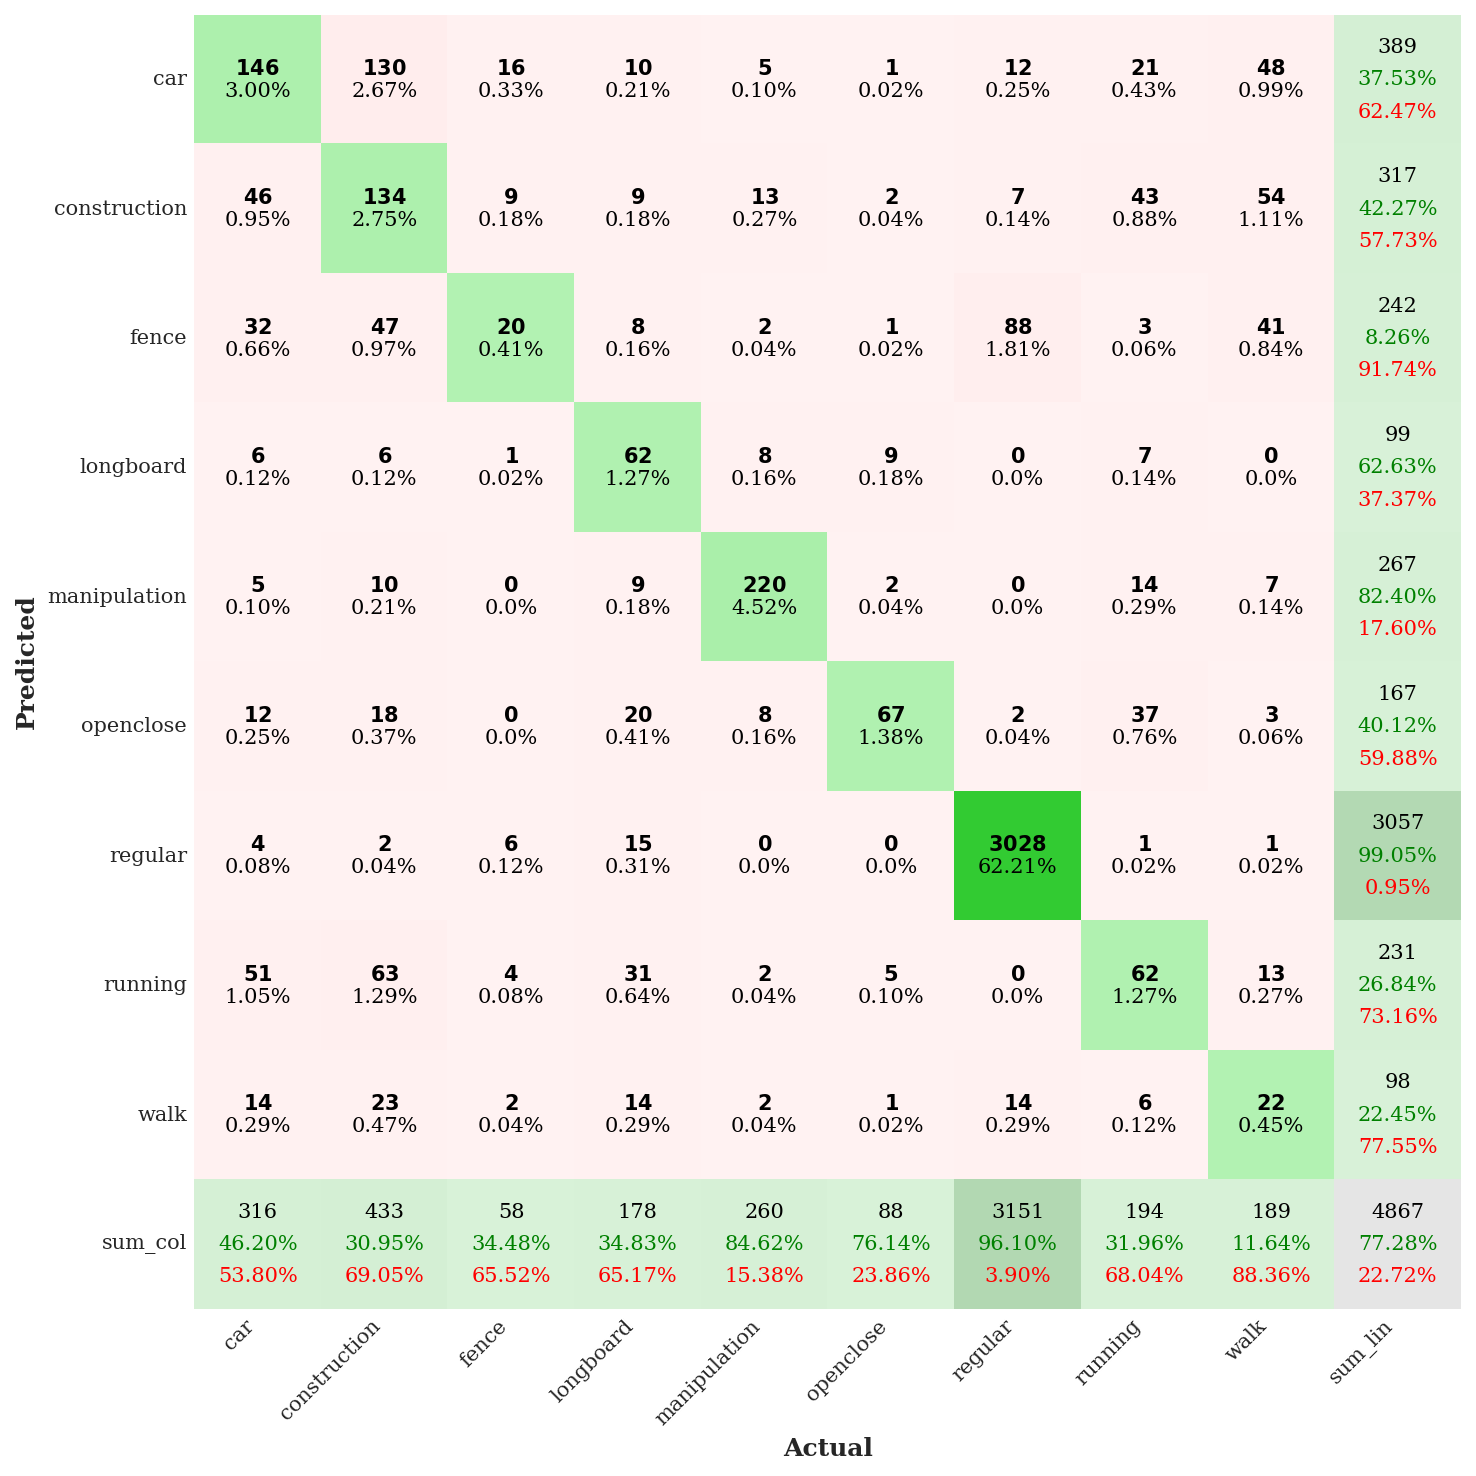


9-way 15-shot Confusion Matrix
Accuracy: 0.7728
Balanced Accuracy: 0.4952
F1 Macro: 0.4614

✓ Saved: paper_figures/siamese_9way_15shot_confusion_matrix.pdf


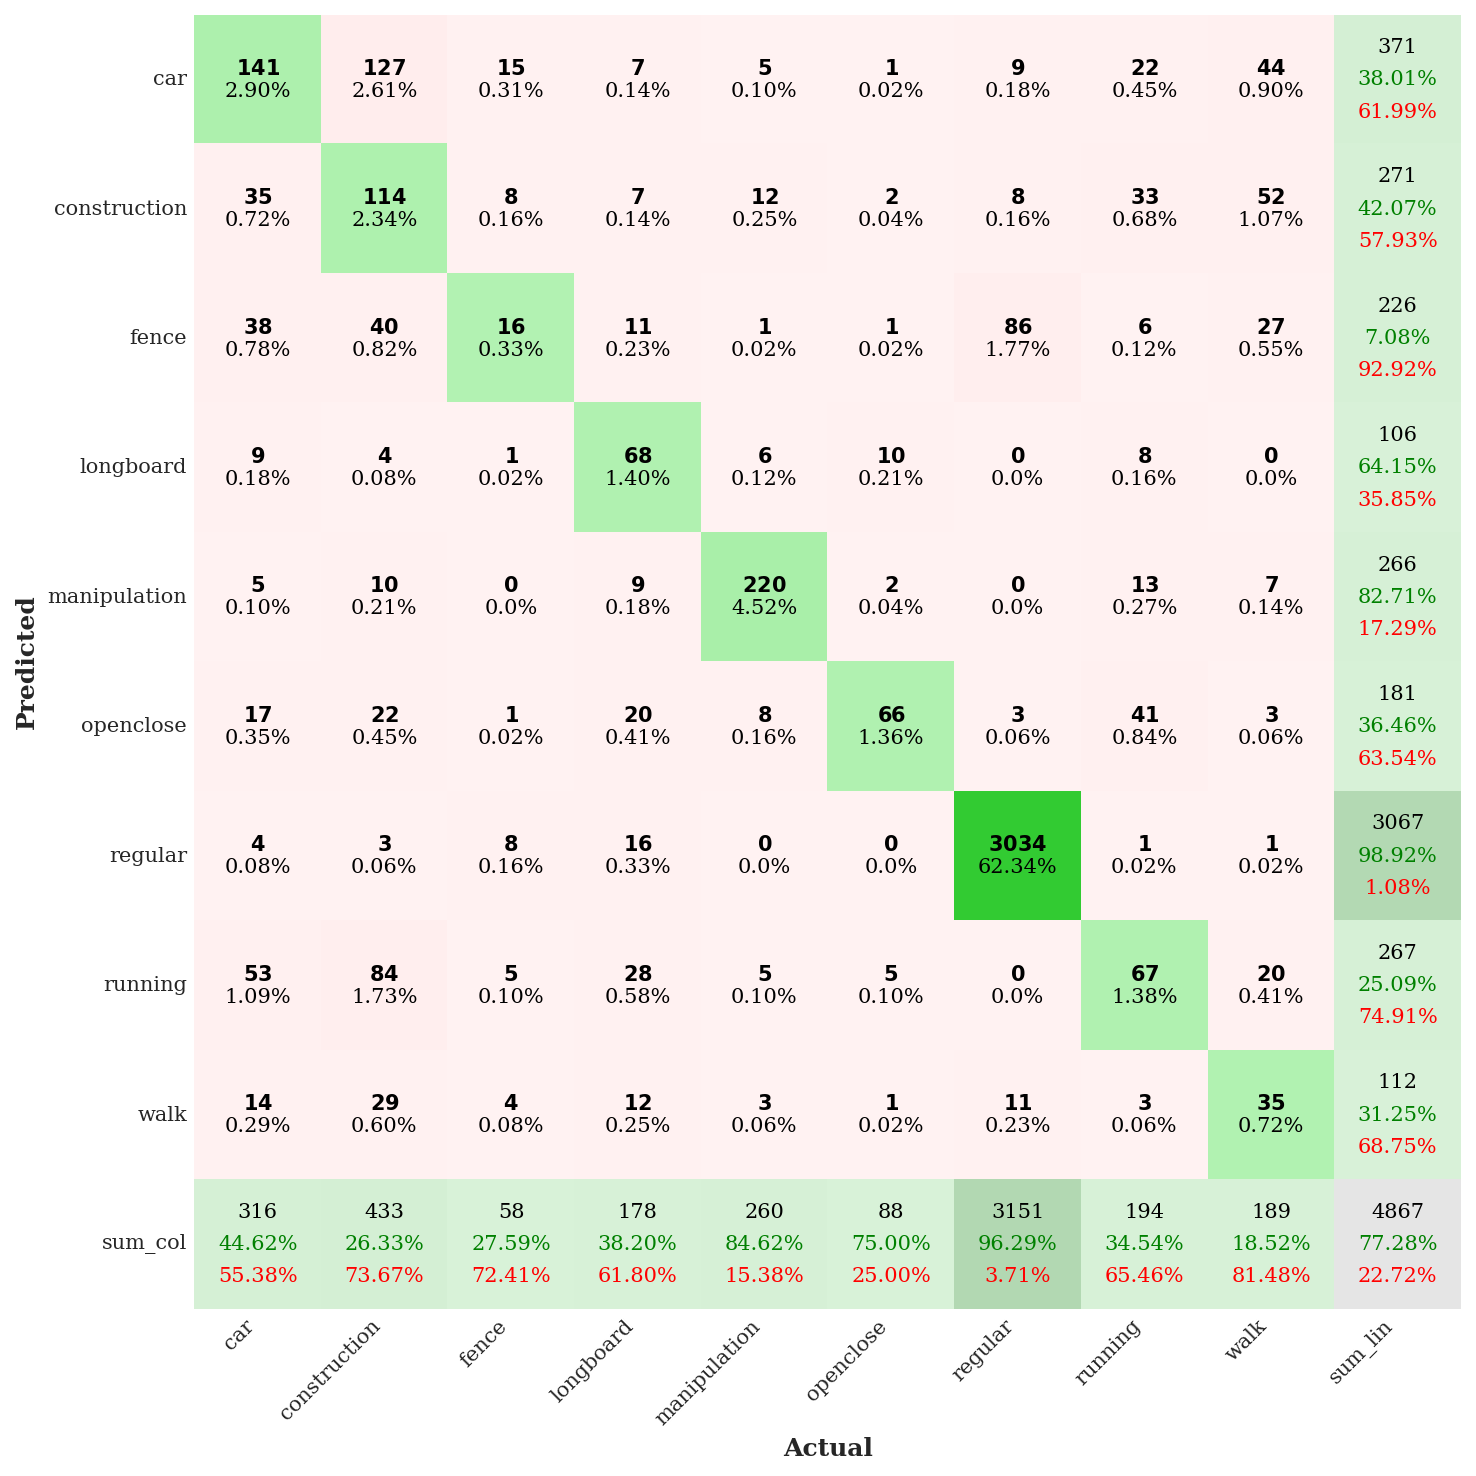


9-way 20-shot Confusion Matrix
Accuracy: 0.7775
Balanced Accuracy: 0.5074
F1 Macro: 0.4739

✓ Saved: paper_figures/siamese_9way_20shot_confusion_matrix.pdf


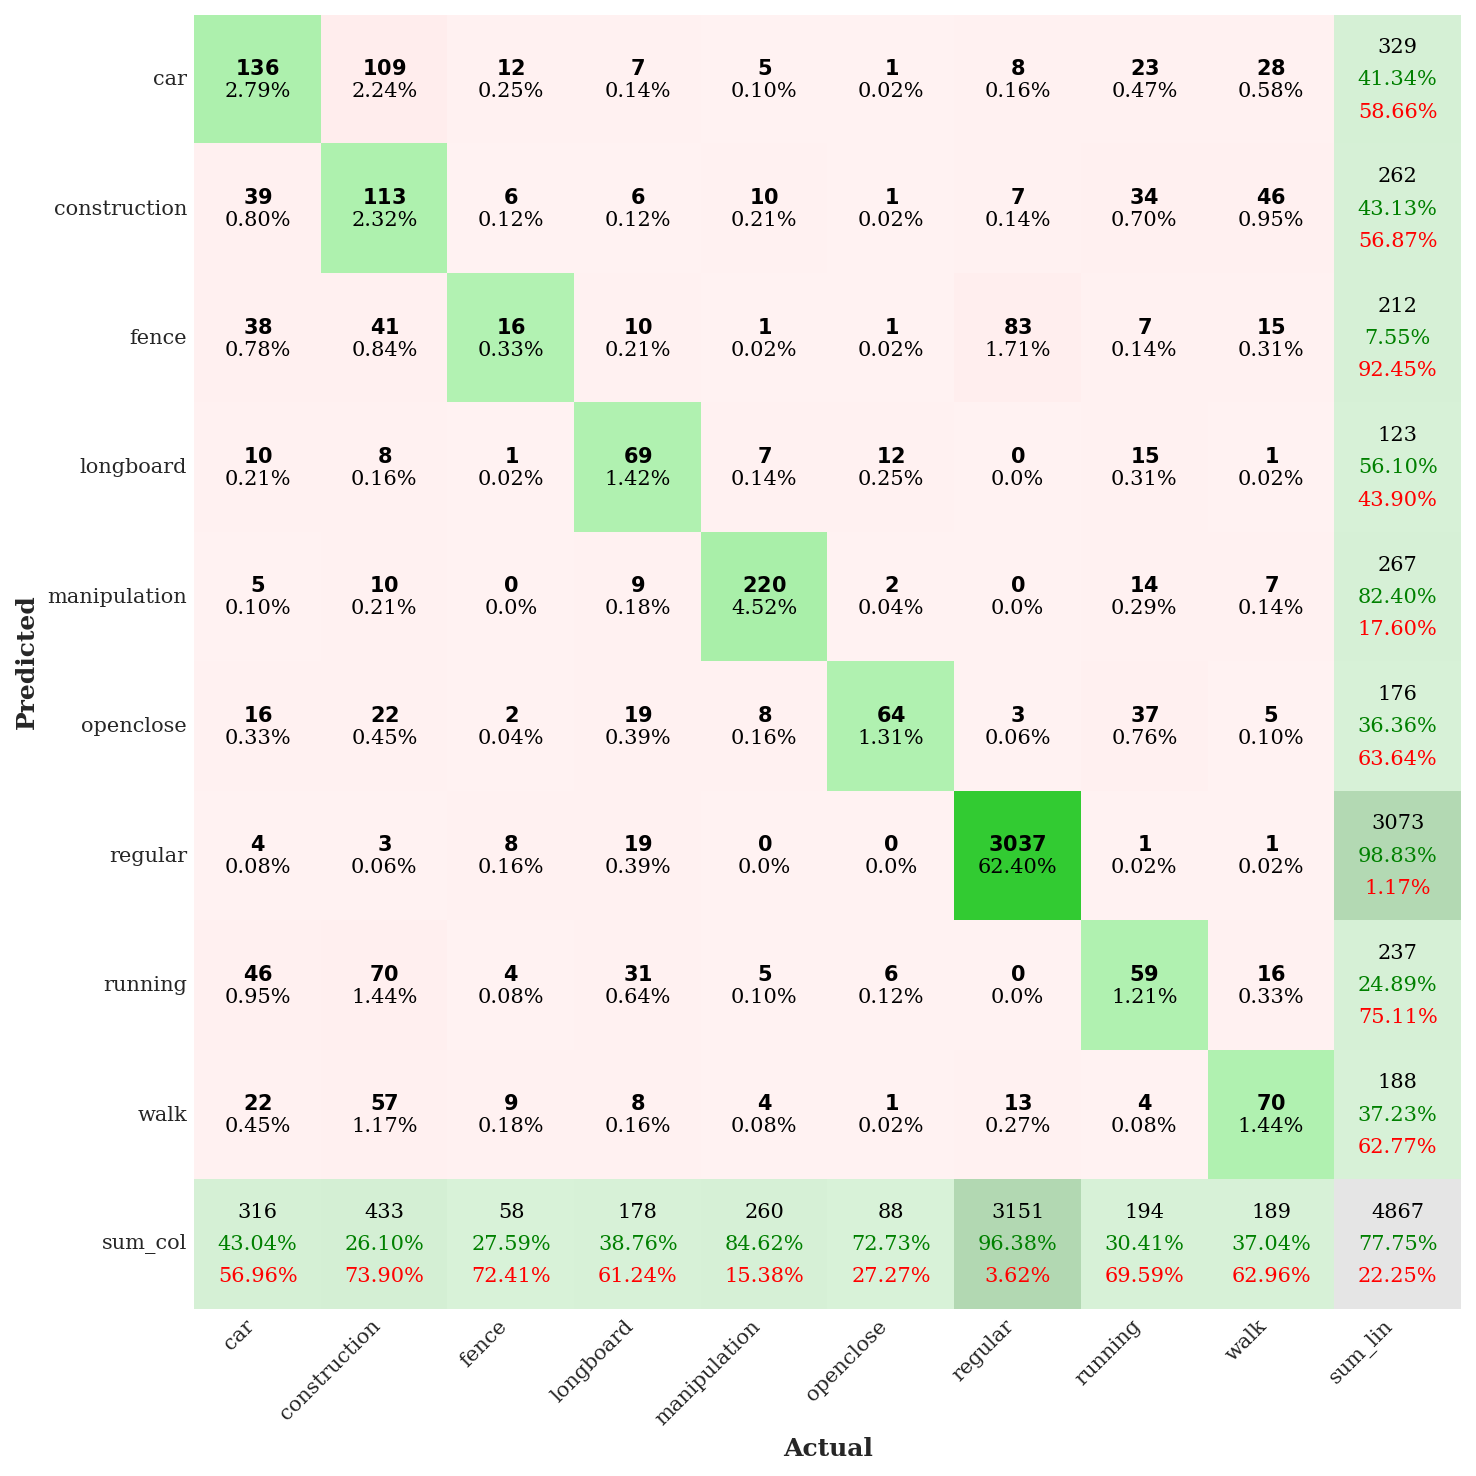

In [21]:
# Plot confusion matrices for 9-way K-shot configurations
if full_test_results is not None:
    class_names = ['car', 'construction', 'fence', 'longboard', 'manipulation', 
                   'openclose', 'regular', 'running', 'walk']
    
    # K-shot values to plot
    k_shots = [1, 5, 10, 15, 20]
    
    for k in k_shots:
        config_key = f'9way_{k}shot'
        
        if config_key in full_test_results:
            plt.close('all')
            
            result = full_test_results[config_key]
            cm = result['confusion_matrix']
            
            print(f"\n9-way {k}-shot Confusion Matrix")
            print(f"Accuracy: {result['accuracy']:.4f}")
            print(f"Balanced Accuracy: {result['balanced_accuracy']:.4f}")
            print(f"F1 Macro: {result['f1_macro']:.4f}")
            print()
            
            plot_from_confusion_matrix(
                cm, 
                columns=class_names,
                figsize=[10, 10], 
                fz=10, 
                lw=1, 
                show_null_values=2, 
                pred_val_axis='lin'
            )
            
            plt.tight_layout()
            plt.savefig(f'{OUTPUT_DIR}/siamese_9way_{k}shot_confusion_matrix.pdf', 
                       bbox_inches='tight', dpi=300)
            print(f"✓ Saved: {OUTPUT_DIR}/siamese_9way_{k}shot_confusion_matrix.pdf")
            plt.show()
        else:
            print(f"⚠ {config_key} results not found")
else:
    print("⚠ Full test results not available")

 Complete summary of all results from MS-SNN

In [27]:
# Complete Summary of All Siamese Results
if full_test_results is not None:
    print('='*100)
    print('COMPLETE SIAMESE NETWORK RESULTS SUMMARY')
    print('='*100)
    
    # Classification Results (9-way K-shot)
    print('\n' + '='*100)
    print('CLASSIFICATION RESULTS (9-way K-shot)')
    print('='*100)
    print(f"{'K-shot':<10} {'Accuracy':>12} {'Bal. Acc':>12} {'F1 Macro':>12} {'F1 Weighted':>12}")
    print('-'*100)
    
    for k in [1, 5, 10, 15, 20]:
        config_key = f'9way_{k}shot'
        if config_key in full_test_results:
            res = full_test_results[config_key]
            print(f"{k:>2}-shot    {res['accuracy']:>12.4f} {res['balanced_accuracy']:>12.4f} "
                  f"{res['f1_macro']:>12.4f} {res['f1_weighted']:>12.4f}")
    
    # Anomaly Detection Results (Binary: Regular vs Others)
    if 'anomaly_detection' in full_test_results:
        print('\n' + '='*100)
        print('ANOMALY DETECTION RESULTS (Binary Classification: Regular vs Others)')
        print('='*100)
        print(f"{'K-shot':<10} {'Accuracy':>12} {'Bal. Acc':>12} {'F1 Score':>12} {'Precision':>12} {'Recall':>12}")
        print('-'*100)
        
        for k in [1, 5, 10, 15, 20]:
            key = f'anomaly_{k}shot'
            if key in full_test_results['anomaly_detection']:
                res = full_test_results['anomaly_detection'][key]
                print(f"{k:>2}-shot    {res.get('accuracy', 0):>12.4f} {res.get('balanced_accuracy', 0):>12.4f} "
                      f"{res['f1']:>12.4f} {res['precision']:>12.4f} {res['recall']:>12.4f}")
    
    # Detailed breakdown for best configuration (20-shot)
    print('\n' + '='*100)
    print('DETAILED BREAKDOWN - BEST CONFIGURATION (9-way 20-shot)')
    print('='*100)
    if '9way_20shot' in full_test_results:
        res = full_test_results['9way_20shot']
        print(f"Test Samples:        {len(res['predictions']):,}")
        print(f"Accuracy:            {res['accuracy']:.4f} ({res['accuracy']*100:.2f}%)")
        print(f"Balanced Accuracy:   {res['balanced_accuracy']:.4f} ({res['balanced_accuracy']*100:.2f}%)")
        print(f"F1 Score (Macro):    {res['f1_macro']:.4f}")
        print(f"F1 Score (Weighted): {res['f1_weighted']:.4f}")
        
        # Per-class breakdown if available
        if 'per_class_metrics' in res:
            print('\nPer-Class Performance:')
            class_names = ['car', 'construction', 'fence', 'longboard', 'manipulation', 
                          'openclose', 'regular', 'running', 'walk']
            print(f"{'Class':<15} {'Precision':>12} {'Recall':>12} {'F1-Score':>12} {'Support':>10}")
            print('-'*100)
            for i, cls in enumerate(class_names):
                if cls in res['per_class_metrics']:
                    m = res['per_class_metrics'][cls]
                    print(f"{cls:<15} {m['precision']:>12.4f} {m['recall']:>12.4f} "
                          f"{m['f1-score']:>12.4f} {m['support']:>10}")
    
    print('='*100)
    
    # Summary comparison
    print('\n' + '='*100)
    print('KEY INSIGHTS')
    print('='*100)
    print('Classification (9-way):')
    if '9way_1shot' in full_test_results and '9way_20shot' in full_test_results:
        acc_1 = full_test_results['9way_1shot']['accuracy']
        acc_20 = full_test_results['9way_20shot']['accuracy']
        improvement = ((acc_20 - acc_1) / acc_1) * 100
        print(f"  • Accuracy improves from {acc_1:.4f} (1-shot) to {acc_20:.4f} (20-shot)")
        print(f"  • Relative improvement: {improvement:.1f}%")
    
    if 'anomaly_detection' in full_test_results:
        print('\nAnomaly Detection (Binary):')
        if 'anomaly_1shot' in full_test_results['anomaly_detection'] and 'anomaly_20shot' in full_test_results['anomaly_detection']:
            f1_1 = full_test_results['anomaly_detection']['anomaly_1shot']['f1']
            f1_20 = full_test_results['anomaly_detection']['anomaly_20shot']['f1']
            improvement_ad = ((f1_20 - f1_1) / f1_1) * 100
            print(f"  • F1 improves from {f1_1:.4f} (1-shot) to {f1_20:.4f} (20-shot)")
            print(f"  • Relative improvement: {improvement_ad:.1f}%")
    
    print('='*100)
else:
    print("⚠ Full test results not available")

COMPLETE SIAMESE NETWORK RESULTS SUMMARY

CLASSIFICATION RESULTS (9-way K-shot)
K-shot         Accuracy     Bal. Acc     F1 Macro  F1 Weighted
----------------------------------------------------------------------------------------------------
 1-shot          0.7446       0.4500       0.3882       0.7445
 5-shot          0.7573       0.4581       0.4234       0.7636
10-shot          0.7728       0.4966       0.4593       0.7799
15-shot          0.7728       0.4952       0.4614       0.7803
20-shot          0.7775       0.5074       0.4739       0.7850

ANOMALY DETECTION RESULTS (Binary Classification: Regular vs Others)
K-shot         Accuracy     Bal. Acc     F1 Score    Precision       Recall
----------------------------------------------------------------------------------------------------
 1-shot          0.9729       0.9745       0.9622       0.9449       0.9802
 5-shot          0.9679       0.9714       0.9558       0.9300       0.9831
10-shot          0.9688       0.9720      

#### Grouped Bar Chart: All Metrics Comparison

✓ Saved: paper_figures/grouped_comparison_all_metrics.pdf


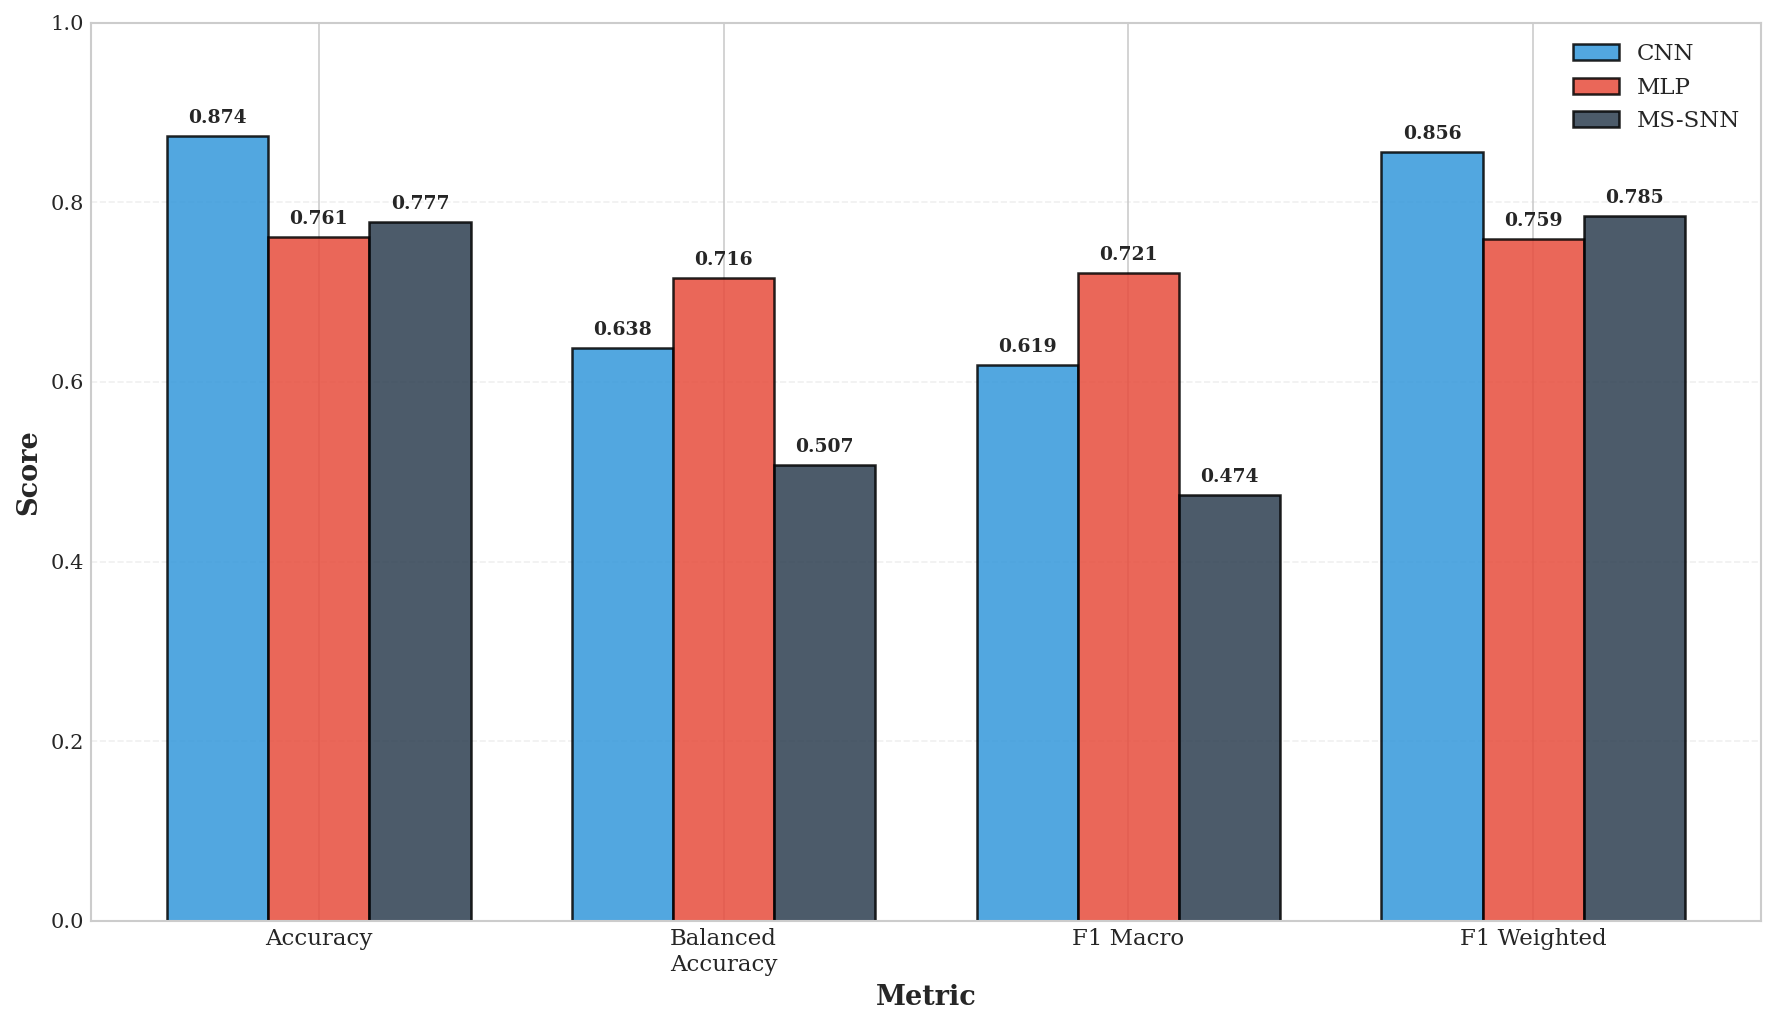


GROUPED METRICS COMPARISON (Full Test Set)
Metric                           CNN             MLP          MS-SNN
------------------------------------------------------------------------------------------
Accuracy                      0.8739          0.7608          0.7775
Balanced Accuracy             0.6378          0.7157          0.5074
F1 Macro                      0.6192          0.7212          0.4739
F1 Weighted                   0.8563          0.7586          0.7850


In [22]:
# Grouped Bar Chart: CNN vs MLP vs MS-SNN - All 4 Metrics
# Metrics on X-axis, 3 bars per metric (one for each model)
# Using Siamese full test results (9-way 20-shot)

if full_test_results is not None and '9way_20shot' in full_test_results:
    # Prepare data - grouped by metric
    metrics = ['Accuracy', 'Balanced\nAccuracy', 'F1 Macro', 'F1 Weighted']
    
    cnn_values = [
        cnn_results['test']['accuracy'] if cnn_results['test'] else 0,
        cnn_results['test']['balanced_accuracy'] if cnn_results['test'] else 0,
        cnn_results['test']['f1_macro'] if cnn_results['test'] else 0,
        cnn_results['test']['f1_weighted'] if cnn_results['test'] else 0
    ]
    
    mlp_values = [
        mlp_results['test']['accuracy'] if mlp_results['test'] else 0,
        mlp_results['test']['balanced_accuracy'] if mlp_results['test'] else 0,
        mlp_results['test']['f1_macro'] if mlp_results['test'] else 0,
        mlp_results['test']['f1_weighted'] if mlp_results['test'] else 0
    ]
    
    # Use full test set results (9-way 20-shot)
    siamese_full = full_test_results['9way_20shot']
    siamese_values = [
        siamese_full['accuracy'],
        siamese_full['balanced_accuracy'],
        siamese_full['f1_macro'],
        siamese_full['f1_weighted']
    ]
    
    # Set up the bar positions
    x = np.arange(len(metrics))
    width = 0.25  # width of each bar
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Colors: blue, red, black
    colors = ['#3498db', '#e74c3c', '#2c3e50']
    
    # Plot bars for each model
    bars1 = ax.bar(x - width, cnn_values, width, label='CNN', color=colors[0], 
                   alpha=0.85, edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x, mlp_values, width, label='MLP', color=colors[1], 
                   alpha=0.85, edgecolor='black', linewidth=1.2)
    bars3 = ax.bar(x + width, siamese_values, width, label='MS-SNN', 
                   color=colors[2], alpha=0.85, edgecolor='black', linewidth=1.2)
    
    # Add value labels on top of bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim([0, 1.0])
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/grouped_comparison_all_metrics.pdf', bbox_inches='tight', dpi=300)
    print(f"✓ Saved: {OUTPUT_DIR}/grouped_comparison_all_metrics.pdf")
    plt.show()
    
    # Print summary
    print("\n" + "="*90)
    print("GROUPED METRICS COMPARISON (Full Test Set)")
    print("="*90)
    print(f"{'Metric':<20} {'CNN':>15} {'MLP':>15} {'MS-SNN':>15}")
    print("-"*90)
    for i, metric in enumerate(metrics):
        metric_clean = metric.replace('\n', ' ')
        print(f"{metric_clean:<20} {cnn_values[i]:>15.4f} {mlp_values[i]:>15.4f} {siamese_values[i]:>15.4f}")
    print("="*90)
else:
    print("⚠ Full test results not available for comparison")

#### IEEE Table: Final Results Comparison

In [ ]:
# Generate IEEE-formatted table for 3 models: CNN, MLP, MS-SNN
# All using full test set (4867 samples)

if full_test_results is not None and '9way_20shot' in full_test_results:
    print("=" * 80)
    print("TABLE I")
    print("CLASSIFICATION RESULTS ON DAS DATASET (FULL TEST SET)")
    print("=" * 80)
    print(f"{'Model':<15} {'Accuracy':>12} {'Bal. Acc':>12} {'F1 Macro':>12} {'F1 Weighted':>12}")
    print("-" * 80)
    
    # CNN results
    if cnn_results['test'] is not None:
        cnn = cnn_results['test']
        print(f"{'CNN':<15} {cnn['accuracy']:>12.4f} {cnn['balanced_accuracy']:>12.4f} "
              f"{cnn['f1_macro']:>12.4f} {cnn['f1_weighted']:>12.4f}")
    
    # MLP results
    if mlp_results['test'] is not None:
        mlp = mlp_results['test']
        print(f"{'MLP':<15} {mlp['accuracy']:>12.4f} {mlp['balanced_accuracy']:>12.4f} "
              f"{mlp['f1_macro']:>12.4f} {mlp['f1_weighted']:>12.4f}")
    
    # MS-SNN results (9-way 20-shot on full test set)
    mssnn = full_test_results['9way_20shot']
    print(f"{'MS-SNN':<15} {mssnn['accuracy']:>12.4f} {mssnn['balanced_accuracy']:>12.4f} "
          f"{mssnn['f1_macro']:>12.4f} {mssnn['f1_weighted']:>12.4f}")
    
    print("-" * 80)
    print(f"{'Test samples:':<15} {len(cnn['predictions']):>12,} {len(mlp['predictions']):>12,} "
          f"{len(mssnn['predictions']):>12,}")
    print("=" * 80)
    print("\nNotes:")
    print("- All models evaluated on the same full test set (4867 samples, 9 classes)")
    print("- MS-SNN: Multi-Similarity Siamese Network (9-way 20-shot)")
    print("- CNN and MLP: Standard supervised classification")
    
    # LaTeX table generation with MS-SNN K-shot configurations
    latex_table = r'''\begin{table*}[t]
\centering
\caption{Numerical results of the compared models}
\label{tab:results_comparison}
\begin{tabular}{|l|c|c|ccccc|}
\hline
\textbf{Metric} & \textbf{CNN} & \textbf{MLP} & \multicolumn{5}{c|}{\textbf{MS-SNN}} \\
\cline{4-8}
 &  &  & \textbf{9w-1s} & \textbf{9w-5s} & \textbf{9w-10s} & \textbf{9w-15s} & \textbf{9w-20s} \\
\hline
'''
    
    # Get values for all K-shot configurations
    mssnn_values = {}
    for k in [1, 5, 10, 15, 20]:
        key = f'9way_{k}shot'
        if key in full_test_results:
            mssnn_values[k] = full_test_results[key]
    
    # Accuracy row
    if cnn_results['test'] is not None and mlp_results['test'] is not None:
        cnn = cnn_results['test']
        mlp = mlp_results['test']
        
        latex_table += f"Accuracy (\\%) & {cnn['accuracy']*100:.2f} & {mlp['accuracy']*100:.2f}"
        for k in [1, 5, 10, 15, 20]:
            if k in mssnn_values:
                latex_table += f" & {mssnn_values[k]['accuracy']*100:.2f}"
        latex_table += " \\\\\n\\hline\n"
        
        # Balanced Accuracy row
        latex_table += f"Balanced Acc. (\\%) & {cnn['balanced_accuracy']*100:.2f} & {mlp['balanced_accuracy']*100:.2f}"
        for k in [1, 5, 10, 15, 20]:
            if k in mssnn_values:
                latex_table += f" & {mssnn_values[k]['balanced_accuracy']*100:.2f}"
        latex_table += " \\\\\n\\hline\n"
        
        # F1 Macro row
        latex_table += f"F1 Macro (\\%) & {cnn['f1_macro']*100:.2f} & {mlp['f1_macro']*100:.2f}"
        for k in [1, 5, 10, 15, 20]:
            if k in mssnn_values:
                latex_table += f" & {mssnn_values[k]['f1_macro']*100:.2f}"
        latex_table += " \\\\\n\\hline\n"
        
        # F1 Weighted row
        latex_table += f"F1 Weighted (\\%) & {cnn['f1_weighted']*100:.2f} & {mlp['f1_weighted']*100:.2f}"
        for k in [1, 5, 10, 15, 20]:
            if k in mssnn_values:
                latex_table += f" & {mssnn_values[k]['f1_weighted']*100:.2f}"
        latex_table += " \\\\\n\\hline\n"
    
    latex_table += r'''\end{tabular}
\\[2mm]
{\small
\begin{tabular}{@{}l@{}}
\textit{Note:} 9w = 9-way; 1s/5s/10s/15s/20s = 1-shot/5-shot/10-shot/15-shot/20-shot
\end{tabular}
}
\end{table*}
'''
    
    # Save LaTeX table
    with open(f'{OUTPUT_DIR}/classification_results_table.tex', 'w') as f:
        f.write(latex_table)
    print(f"\n✓ Saved LaTeX table: {OUTPUT_DIR}/classification_results_table.tex")
    
else:
    print("⚠ Full test results not available for table generation")

TABLE I
CLASSIFICATION RESULTS ON DAS DATASET (FULL TEST SET)
Model               Accuracy     Bal. Acc     F1 Macro  F1 Weighted
--------------------------------------------------------------------------------
CNN                   0.8739       0.6378       0.6192       0.8563
MLP                   0.7608       0.7157       0.7212       0.7586
MS-SNN                0.7775       0.5074       0.4739       0.7850
--------------------------------------------------------------------------------
Test samples:         32,447       11,865        4,867

Notes:
- All models evaluated on the same full test set (4867 samples, 9 classes)
- MS-SNN: Multi-Similarity Siamese Network (9-way 20-shot)
- CNN and MLP: Standard supervised classification

✓ Saved LaTeX table: paper_figures/classification_results_table.tex


### IEEE-formated LATEX table of Models' Hyperparameters

In [ ]:
# Generate IEEE-formatted hyperparameters table
if full_test_results is not None:
    print("=" * 80)
    print("TABLE II")
    print("HYPERPARAMETERS OF THE COMPARED MODELS")
    print("=" * 80)
    
    # Create LaTeX table for hyperparameters
    latex_table_hp = r'''\begin{table*}[t]
\centering
\caption{Hyperparameters of the compared models}
\label{tab:hyperparameters}
\begin{tabular}{|l|c|c|c|}
\hline
\textbf{Hyperparameter} & \textbf{CNN} & \textbf{MLP} & \textbf{MS-SNN} \\
\hline
Dropout Rate & 0.5 & 0.3 & 0.5 \\
\hline
Batch Size & 64 & 256 & 64 \\
\hline
Learning Rate & 0.001 & 0.001 & 0.0001 \\
\hline
Optimizer & Adam & Adam & Adam \\
\hline
Loss Function & Cross-Entropy & Cross-Entropy & Triplet Loss \\
\hline
Epochs & 100 & 100 & 100 \\
\hline
\end{tabular}
\end{table*}
'''
    
    # Save hyperparameters table
    with open(f'{OUTPUT_DIR}/hyperparameters_table.tex', 'w') as f:
        f.write(latex_table_hp)
    print(f"✓ Saved LaTeX hyperparameters table: {OUTPUT_DIR}/hyperparameters_table.tex")
    
    # Print hyperparameters summary
    print("\nHyperparameters Summary:")
    print("-" * 80)
    print(f"{'CNN':<20} ResNet-18, Dropout=0.5, LR=0.001, Batch=64")
    print(f"{'MLP':<20} 3 Layers [512,256,128], Dropout=0.3, LR=0.001, Batch=256")
    print(f"{'MS-SNN':<20} Siamese ResNet-18, Emb=128, LR=0.0001, Batch=64, 9w-20s")
    print("=" * 80)
else:
    print("⚠ Full test results not available for table generation")

TABLE II
HYPERPARAMETERS OF THE COMPARED MODELS
✓ Saved LaTeX hyperparameters table: paper_figures/hyperparameters_table.tex

Hyperparameters Summary:
--------------------------------------------------------------------------------
CNN                  ResNet-18, Dropout=0.5, LR=0.001, Batch=64
MLP                  3 Layers [512,256,128], Dropout=0.3, LR=0.001, Batch=256
MS-SNN               Siamese ResNet-18, Emb=128, LR=0.0001, Batch=64, 9w-20s


### IEEE-formatted LATEX table of Confusion Matrices

In [30]:
# Generate separate IEEE-formatted confusion matrices tables for each model
if full_test_results is not None and cnn_results['test'] is not None and mlp_results['test'] is not None:
    print("=" * 80)
    print("CONFUSION MATRICES TABLES (SEPARATE FOR EACH MODEL)")
    print("=" * 80)
    
    # Get class names
    class_names = ['car', 'construction', 'fence', 'longboard', 'manipulation', 
                   'openclose', 'regular', 'running', 'walk']
    n_classes = len(class_names)
    
    # Get confusion matrices
    cm_cnn = cnn_results['test']['confusion_matrix']
    cm_mlp = mlp_results['test']['confusion_matrix']
    cm_mssnn = full_test_results['9way_20shot']['confusion_matrix']
    
    # Function to generate a single confusion matrix LaTeX table
    def cm_to_latex_table(cm, class_names, model_name, table_num):
        """Convert confusion matrix to standalone LaTeX table"""
        n = len(class_names)
        
        # Use abbreviated class names for headers
        abbrev = ['CA', 'CO', 'FE', 'LO', 'MA', 'OP', 'RE', 'RU', 'WA']
        
        latex = r'''\begin{table*}[t]
\centering
\caption{Confusion matrix for ''' + model_name + r''' on the DAS dataset}
\label{tab:confusion_matrix_''' + model_name.lower().replace(' ', '_').replace('-', '_') + r'''}
\begin{tabular}{|l|''' + 'c|'*n + r'''}
\hline
\textbf{True/Pred.}'''
        
        # Header row with predicted class names
        for a in abbrev:
            latex += f' & \\textbf{{{a}}}'
        latex += r' \\' + '\n'
        latex += r'\hline' + '\n'
        
        # Data rows
        for i in range(n):
            latex += f'\\textbf{{{abbrev[i]}}}'
            for j in range(n):
                val = int(cm[i, j])
                # Highlight diagonal elements (correct predictions)
                if i == j:
                    latex += f' & \\textbf{{{val}}}'
                else:
                    latex += f' & {val}'
            latex += r' \\' + '\n'
            latex += r'\hline' + '\n'
        
        latex += r'''\end{tabular}
\\[2mm]
{\small
\begin{tabular}{@{}l@{}}
\textit{Note:} CA=car, CO=construction, FE=fence, LO=longboard, MA=manipulation, \\
OP=openclose, RE=regular, RU=running, WA=walk. \\
Diagonal elements (bold) represent correct predictions.
\end{tabular}
}
\end{table*}
'''
        return latex
    
    # Generate and save CNN confusion matrix table
    print("\nGenerating TABLE III: CNN Confusion Matrix...")
    latex_cm_cnn = cm_to_latex_table(cm_cnn, class_names, 'CNN', 'III')
    with open(f'{OUTPUT_DIR}/confusion_matrix_cnn.tex', 'w') as f:
        f.write(latex_cm_cnn)
    print(f"✓ Saved: {OUTPUT_DIR}/confusion_matrix_cnn.tex")
    
    # Generate and save MLP confusion matrix table
    print("Generating TABLE IV: MLP Confusion Matrix...")
    latex_cm_mlp = cm_to_latex_table(cm_mlp, class_names, 'MLP', 'IV')
    with open(f'{OUTPUT_DIR}/confusion_matrix_mlp.tex', 'w') as f:
        f.write(latex_cm_mlp)
    print(f"✓ Saved: {OUTPUT_DIR}/confusion_matrix_mlp.tex")
    
    # Generate and save MS-SNN confusion matrix table
    print("Generating TABLE V: MS-SNN Confusion Matrix...")
    latex_cm_mssnn = cm_to_latex_table(cm_mssnn, class_names, 'MS-SNN (9-way 20-shot)', 'V')
    with open(f'{OUTPUT_DIR}/confusion_matrix_mssnn.tex', 'w') as f:
        f.write(latex_cm_mssnn)
    print(f"✓ Saved: {OUTPUT_DIR}/confusion_matrix_mssnn.tex")
    
    # Print summary statistics for each model
    print("\n" + "=" * 80)
    print("Confusion Matrix Statistics:")
    print("-" * 80)
    
    for model_name, cm in [('CNN', cm_cnn), ('MLP', cm_mlp), ('MS-SNN', cm_mssnn)]:
        total = np.sum(cm)
        correct = np.trace(cm)
        accuracy = correct / total
        print(f"{model_name:<10} Correct: {correct:>5}/{total:<5} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    print("=" * 80)
    
    # Print per-class accuracy for each model
    print("\nPer-Class Accuracy:")
    print("-" * 80)
    print(f"{'Class':<15} {'CNN':>10} {'MLP':>10} {'MS-SNN':>10}")
    print("-" * 80)
    
    for i, cls in enumerate(class_names):
        cnn_acc = cm_cnn[i, i] / np.sum(cm_cnn[i, :]) if np.sum(cm_cnn[i, :]) > 0 else 0
        mlp_acc = cm_mlp[i, i] / np.sum(cm_mlp[i, :]) if np.sum(cm_mlp[i, :]) > 0 else 0
        mssnn_acc = cm_mssnn[i, i] / np.sum(cm_mssnn[i, :]) if np.sum(cm_mssnn[i, :]) > 0 else 0
        print(f"{cls:<15} {cnn_acc:>10.4f} {mlp_acc:>10.4f} {mssnn_acc:>10.4f}")
    
    print("=" * 80)
    
else:
    print("⚠ Full test results not available for confusion matrices table generation")

CONFUSION MATRICES TABLES (SEPARATE FOR EACH MODEL)

Generating TABLE III: CNN Confusion Matrix...
✓ Saved: paper_figures/confusion_matrix_cnn.tex
Generating TABLE IV: MLP Confusion Matrix...
✓ Saved: paper_figures/confusion_matrix_mlp.tex
Generating TABLE V: MS-SNN Confusion Matrix...
✓ Saved: paper_figures/confusion_matrix_mssnn.tex

Confusion Matrix Statistics:
--------------------------------------------------------------------------------
CNN        Correct: 28357/32447 = 0.8739 (87.39%)
MLP        Correct:  9027/11865 = 0.7608 (76.08%)
MS-SNN     Correct:  3784/4867  = 0.7775 (77.75%)

Per-Class Accuracy:
--------------------------------------------------------------------------------
Class                  CNN        MLP     MS-SNN
--------------------------------------------------------------------------------
car                 0.0954     0.7004     0.4304
construction        0.9462     0.8351     0.2610
fence               0.2028     0.3056     0.2759
longboard           0.8